# Scientific EDA & Risk Profiling

## 1. Context & Objectives
Now that the Master Table has been successfully constructed, we have a dataset comprising 307,511 loan applications enriched with 222 features derived from both internal (Home Credit) and external (Credit Bureau) sources.

The goal of this phase is to move beyond simple visualization. We perform a Scientific Exploratory Data Analysis (EDA) to assess data reliability, handle feature redundancies, and identify the strongest drivers of credit default risk. This phase is critical to ensure that the future model remains stable, interpretable, and fully compliant with banking regulations.

## 2. Analytical Key Questions
* **Data Health:** Are the 222 features reliable? How do we handle high sparsity and missing values across aggregated columns?
* **Predictive Power:** Which features—especially our engineered variables—show the highest correlation or Information Value (IV) with the TARGET?
* **Collinearity Control:** How do we handle perfectly redundant features (such as raw temporal days versus transformed years) to protect model stability?
* **Ethical Lending & Bias:** Do our top predictive drivers introduce systemic discrimination against protected demographic groups?

---

## EDA Operational Roadmap

### I. Data Integrity & Sparsity Audit
* **Structure Validation:** Verification of data types and uniqueness of the primary key (`SK_ID_CURR`).
* **Missing Value Analysis:** Deep dive into sparsity, distinguishing between error-based missingness and logical-based missingness (e.g., absence of previous credit history).
* **Initial Filtering:** Removal of near-zero variance columns and features with extreme non-logical missing values.

### II. Target Profiling & Baseline Assessment
* **Class Imbalance:** Quantification of the baseline default rate (established at 8.07%).
* **Modeling Strategy:** Definition of validation constraints, confirming the mandatory use of Stratified Cross-Validation and cost-sensitive learning weights.

### III. Univariate Risk Profiling & Feature Refinement
* **Temporal Transformations:** Converting raw operational features into business-interpretable metrics (e.g., transforming `DAYS_BIRTH` into `YEARS_BIRTH`).
* **Redundancy Elimination:** Dropping highly collinear base features (such as `DAYS_BIRTH`) to optimize feature importance interpretation and protect linear baselines.
* **Risk Slope Validation:** Segmenting continuous features into quantile buckets to confirm stable, monotonic relationships with credit default risk.

### IV. Bivariate Analysis & Multicollinearity Check
* **Correlation Mapping:** Identifying multi-feature correlations to prevent feature bloating.
* **Categorical Risk Assessment:** Analyzing default rate distributions across non-numeric profiles.

### V. Ethical Framework: Bias Detection
* **Sensitive Attribute Identification:** Isolating protected demographic fields (such as Age, Gender, or Social Status).
* **Disparate Impact Assessment:** Evaluating if high-performing risk predictors inadvertently penalize specific sub-populations.
* **Fair Lending Compliance:** Auditing systemic bias before feeding features into the final LightGBM pipeline.


## **I. Data Integrity & Sparsity Audit**

In [3]:
# Loading the dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path
import gc

# 1. Root path
notebook_dir = Path(".").resolve()
project_root = notebook_dir.parent.parent

# 2. Add to sys.path to allow config import 
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from config.logging import get_logger

# Initialize
logger = get_logger("Scientific-EDA")
interim_path = project_root / "data/interim/df_master_uncleaned.parquet"

# Load the Master Table
logger.info(f"Loading Master Table from {interim_path}")
df = pd.read_parquet(interim_path)

print(f"Data Loaded. Shape: {df.shape}")

{"timestamp": "2026-07-15 01:27:22", "level": "INFO", "logger": "Scientific-EDA", "module": "3644519192", "function": "<module>", "message": "Loading Master Table from C:\\Users\\Yves-Ricky\\Desktop\\credit_project\\data\\interim\\df_master_uncleaned.parquet", "name": "Scientific-EDA", "msg": "Loading Master Table from C:\\Users\\Yves-Ricky\\Desktop\\credit_project\\data\\interim\\df_master_uncleaned.parquet", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\3644519192.py", "filename": "3644519192.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 25, "funcName": "<module>", "created": 1784071642.9100428, "msecs": 910.0, "relativeCreated": 967791.7397022247, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}
Data Loaded. Shape: (307511, 222)


In [4]:
# 1. Unique ID Check
unique_ids = df['SK_ID_CURR'].nunique()
total_rows = len(df)
is_unique = unique_ids == total_rows

logger.info(f"ID Uniqueness Check: {is_unique} ({unique_ids} unique IDs for {total_rows} rows)")

# 2. Data Types Distribution
dtype_counts = df.dtypes.value_counts()
print("\n--- Data Types Distribution ---")
print(dtype_counts)

# Identify categorical and numerical columns for future steps
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

logger.info(f"Detected {len(num_cols)} numerical and {len(cat_cols)} categorical features.")

{"timestamp": "2026-07-15 01:27:24", "level": "INFO", "logger": "Scientific-EDA", "module": "3994974652", "function": "<module>", "message": "ID Uniqueness Check: True (307511 unique IDs for 307511 rows)", "name": "Scientific-EDA", "msg": "ID Uniqueness Check: True (307511 unique IDs for 307511 rows)", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\3994974652.py", "filename": "3994974652.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 6, "funcName": "<module>", "created": 1784071644.3226607, "msecs": 322.0, "relativeCreated": 969204.357624054, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}

--- Data Types Distribution ---
float64    165
int64       41
object      16
Name: count, dtype: int64
{"timestamp": "2026-07-15 01:27:25", "level": "INFO", "logger": "Scientific-EDA", "module": "3994974652", "function": "<module>", "message": "Detected 206 


--- Top 20 Most Sparse Features ---
                                  Feature  Missing_Count  Missing_Pct
0       PRV_RATE_INTEREST_PRIVILEGED_MEAN         302902    98.501192
1          PRV_RATE_INTEREST_PRIMARY_MEAN         302902    98.501192
2   PRV_AMT_CREDIT_LIMIT_ACTUAL_MEAN_MEAN         229577    74.656516
3                   PRV_SK_DPD_MAX_Y_MEAN         229577    74.656516
4               PRV_AMT_BALANCE_MEAN_MEAN         229577    74.656516
5                PRV_AMT_BALANCE_MAX_MEAN         229577    74.656516
6          PRV_CC_SENT PROPOSAL_MEAN_MEAN         229577    74.656516
7                 PRV_CC_SIGNED_MEAN_MEAN         229577    74.656516
8               PRV_CC_APPROVED_MEAN_MEAN         229577    74.656516
9              PRV_CC_COMPLETED_MEAN_MEAN         229577    74.656516
10                PRV_CC_ACTIVE_MEAN_MEAN         229577    74.656516
11                 PRV_SK_DPD_MEAN_Y_MEAN         229577    74.656516
12   PRV_AMT_CREDIT_LIMIT_ACTUAL_MAX_MEAN         229

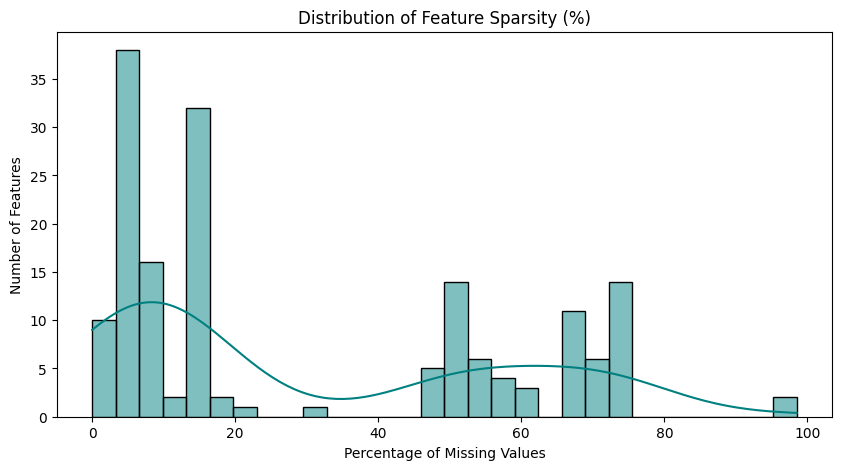

In [5]:
# 2-Missing Value Analysis (Sparsity Audit)
# Calculate missing values
missing_stats = df.isnull().sum().sort_values(ascending=False)
missing_table = pd.DataFrame({
    'Feature': missing_stats.index,
    'Missing_Count': missing_stats.values,
    'Missing_Pct': (missing_stats.values / total_rows) * 100
})

# Filter only features with missing values
missing_table = missing_table[missing_table['Missing_Count'] > 0]

print(f"\n--- Top 20 Most Sparse Features ---")
print(missing_table.head(20))

# Visualization of sparsity distribution
plt.figure(figsize=(10, 5))
sns.histplot(missing_table['Missing_Pct'], bins=30, kde=True, color='teal')
plt.title("Distribution of Feature Sparsity (%)")
plt.xlabel("Percentage of Missing Values")
plt.ylabel("Number of Features")
plt.show()

In [6]:
# 3-Initial filtering
# 1. Identify columns with > 90% missing values
too_sparse_cols = missing_table[missing_table['Missing_Pct'] > 90]['Feature'].tolist()
logger.warning(f"Found {len(too_sparse_cols)} features with > 90% missing values: {too_sparse_cols}")
print(too_sparse_cols)

# 2. Identify constant columns (Zero Variance)
# A column with the same value everywhere brings 0 information
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
logger.warning(f"Found {len(constant_cols)} constant features to remove: {constant_cols}")
print(constant_cols)

# 3. Decision: Drop/Keep
# We drop constants and extreme sparse columns that are not logical signals
cols_to_drop = list(set(too_sparse_cols + constant_cols))
df_cleaned = df.drop(columns=cols_to_drop)

logger.info(f"Data Integrity complete. {len(cols_to_drop)} columns removed. New Shape: {df_cleaned.shape}")

{"timestamp": "2026-07-15 01:27:25", "level": "WARNING", "logger": "Scientific-EDA", "module": "2592058054", "function": "<module>", "message": "Found 2 features with > 90% missing values: ['PRV_RATE_INTEREST_PRIVILEGED_MEAN', 'PRV_RATE_INTEREST_PRIMARY_MEAN']", "name": "Scientific-EDA", "msg": "Found 2 features with > 90% missing values: ['PRV_RATE_INTEREST_PRIVILEGED_MEAN', 'PRV_RATE_INTEREST_PRIMARY_MEAN']", "args": [], "levelname": "WARNING", "levelno": 30, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\2592058054.py", "filename": "2592058054.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 4, "funcName": "<module>", "created": 1784071645.790159, "msecs": 790.0, "relativeCreated": 970671.8559265137, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}
['PRV_RATE_INTEREST_PRIVILEGED_MEAN', 'PRV_RATE_INTEREST_PRIMARY_MEAN']
{"timestamp": "2026-07-15 01:27:27", "level": "WARNING", "logger": "Scien

### Focus: Constant Features & Sparsity Patterns Analysis

#### 1. Eliminating Zero-Variance Features
The code tried to identified several "Constant Features"—columns where the value is the same for all 307,511 records (or contains only one unique value besides `NaN`) and did not find any.
*   **Mathematical Logic**: Machine Learning models learn from **variance**. If a feature $X$ never changes, its correlation with the `TARGET` is strictly zero. 
*   **Impact**: Removing this kind of  columns reduces the computational load and prevents the model from assigning importance to "dead weight" variables that provide no discriminative power between good and bad payers.

#### 2. Deep Dive into the Top 20 Sparse Features
Our sparsity audit reveals three distinct clusters of missing data, each with a different business meaning:

| Cluster | Features | Missing % | Business Interpretation |
| :--- | :--- | :--- | :--- |
| **A. Promotional Rates** | `PRV_RATE_INTEREST_...` | **98.5%** | **Niche Products**: These rates apply only to a tiny fraction of specific loans (e.g., privileged internal staff or high-tier wealth clients). They are too rare for reliable statistical inference. |
| **B. Credit Card Hub** | `PRV_CC_...`, `PRV_AMT_BALANCE_...` | **74.6%** | **Informative Missingness**: Notice that 14 features share the exact same percentage (**74.65%**). This confirms they originated from the same table (`credit_card_balance`). It implies that ~75% of our applicants **never had a credit card** with Home Credit. This "absence of data" is a massive behavioral signal. |
| **C. Building Details** | `COMMONAREA_...`, `NONLIVING_...` | **69.4%** | **Optional Disclosure**: These fields describe technical housing details. Many applicants do not know or choose not to provide this information during the application process. |

#### 3. Filtering Strategy
*   **The 90% Threshold**: Features in **Cluster A** are dropped. With less than 1.5% of data points, they introduce more noise than signal.
*   **The "Logical Signal" Retention**: We choose to **keep Clusters B and C**. 
    *   For **Cluster B**, the `NaN` value itself acts as a feature: it distinguishes "New Customers" from "Returning Revolving Credit Customers." 
    *   Gradient Boosting models (XGBoost/LightGBM) will handle these `NaNs` by learning an optimal "default branch" for clients without credit card history.

**Conclusion**: This step reduced our feature space while preserving the high-value "Sparsity Signals" that are essential for accurate risk assessment.

## **II. Target Profiling (Default Rate)**

{"timestamp": "2026-07-15 01:27:27", "level": "INFO", "logger": "Scientific-EDA", "module": "3964766268", "function": "<module>", "message": "Target Distribution: 282686 Repaid (0), 24825 Defaulted (1)", "name": "Scientific-EDA", "msg": "Target Distribution: 282686 Repaid (0), 24825 Defaulted (1)", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\3964766268.py", "filename": "3964766268.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 5, "funcName": "<module>", "created": 1784071647.6526752, "msecs": 652.0, "relativeCreated": 972534.3720912933, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}
{"timestamp": "2026-07-15 01:27:27", "level": "INFO", "logger": "Scientific-EDA", "module": "3964766268", "function": "<module>", "message": "Global Default Rate: 8.07%", "name": "Scientific-EDA", "msg": "Global Default Rate: 8.07%", "args": [], "levelname": "IN

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\3964766268.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET', data=df_cleaned, palette=['blue', 'red'])


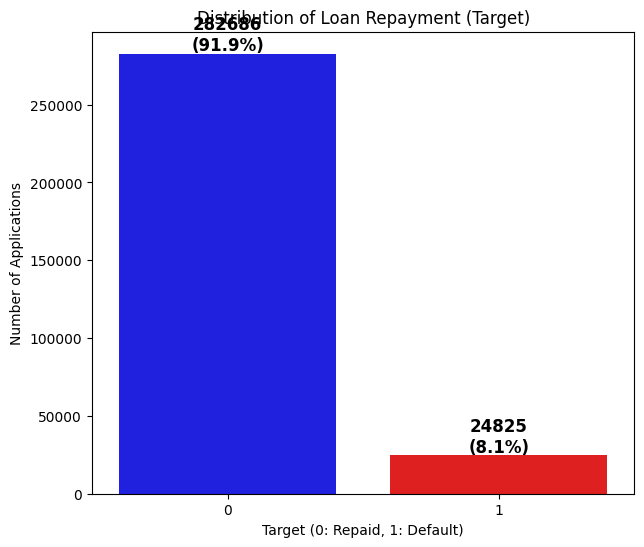

In [7]:
# 1. Calculate Default Rate
target_counts = df_cleaned['TARGET'].value_counts()
default_rate = (target_counts[1] / len(df_cleaned)) * 100

logger.info(f"Target Distribution: {target_counts[0]} Repaid (0), {target_counts[1]} Defaulted (1)")
logger.info(f"Global Default Rate: {default_rate:.2f}%")
print("Default rate", default_rate)

# 2. Visualization
plt.figure(figsize=(7, 6))
sns.countplot(x='TARGET', data=df_cleaned, palette=['blue', 'red'])
plt.title("Distribution of Loan Repayment (Target)")
plt.xlabel("Target (0: Repaid, 1: Default)")
plt.ylabel("Number of Applications")

# Add text labels on bars
for i, count in enumerate(target_counts):
    plt.text(i, count + 2000, f"{count}\n({count/len(df_cleaned)*100:.1f}%)", 
             ha='center', fontsize=12, fontweight='bold')

plt.show()

### Target Profiling: The Imbalance

The `TARGET` variable is our primary objective: it indicates whether a client defaulted on their loan (1) or repaid it on time (0).

**Key Observations:**
*   **Imbalance**: We have a highly imbalanced dataset. **8.1%** of applicants defaulted, while **91.9%** repaid.
*   **The "Accuracy Paradox"**: In this context, an accuracy of 91.9% would be useless. A dummy model that predicts "always 0" would reach 91.9% accuracy but would fail to detect **100% of the risky clients**.
*   **Modeling Implications**:
    1.  **Metric Selection**: We cannot rely on Accuracy. We must use **ROC-AUC**, **Precision-Recall AUC**, or **F1-Score**.
    2.  **Algorithm Tuning**: We will need to use techniques like **Scale_Pos_Weight** (in XGBoost/LightGBM) or **SMOTE/Downsampling** to ensure the model learns the characteristics of the minority class (the defaulters).
    3.  **Cost of Error**: For a bank, a **False Negative** (approving a loan for someone who will default) is much more expensive than a **False Positive** (refusing a loan to someone who would have repaid).

### **III. Univariate Analysis (Financial Distributions)**


#### 1. Methodology: From Observation to Audit
With our dataset expanded from **122 to 220 features**, a manual univariate analysis is no longer efficient. We have implemented a rigorous **Feature Audit Framework** to evaluate every variable against four key dimensions:
*   **Predictive Strength (AUC & IV)**: Measuring the individual ability of a feature to separate "Good" from "Bad" borrowers.
*   **Distribution Shape (Skewness)**: Identifying features that require non-linear transformations (Log, Yeo-Johnson).
*   **Extremity (Kurtosis)**: Detecting "Fat Tails" and extreme financial behaviors that could destabilize model weights.
*   **Categorization (6 Strategic Pillars)**: Organizing features by their business origin to understand where the "Alpha" (predictive signal) comes from.

---

#### 2. The 6 Strategic Pillars of Risk
Every feature is mapped to one of the following pillars to ensure a balanced view of the borrower's profile:
1.  **Financials**: Absolute monetary amounts and counts (`AMT_`, `CNT_`).
2.  **External Scores**: Third-party credit ratings (`EXT_SOURCE_1, 2, 3`).
3.  **Client Profile**: Demographic and employment stability (Age, Seniority).
4.  **Bureau History**: Historical behavior reported by external institutions.
5.  **Previous Applications**: Static data from past loan requests with our bank.
6.  **Internal Aggregations**: Deep behavioral signals from past payments and credit card usage.

---

#### 3. Objective & Decision Gates
The goal of this audit is to feed our **Feature Selection** strategy. We will:
*   **Rank** features by their mathematical "Predictive Power."
*   **Visualize** only the top-performing champions (AUC > 0.60 or high IV).
*   **Identify** problematic distributions (Skewness > 2 or Kurtosis > 10) for targeted preprocessing.

#### 4. Outliers detection
We will use isolation forest to detect outliers

#### The univariate AUC
 measures the performance of a single variable. It ranges from 0 to 1:
* **AUC = 0.50**: The variable has no predictive power (equivalent to a coin toss).
* **AUC > 0.50**: **Direct (positive)** relationship with risk. The higher the value of the variable, the greater the probability of default.
* **AUC < 0.50**: **Inverse (negative)** relationship with risk. The higher the value of the variable, the more creditworthy the customer is considered to be (the risk decreases).

The `predictive_power` score is calculated using the following formula: 
$$\text{predictive\_power} = |AUC - 0.5|$$

This transformation is essential because it allows us to measure the **raw strength** of a variable regardless of the direction of its relationship with the target. It scales the value between $0$ (no predictive power) and $0.5$ (perfect predictive power).

#### IV (Information Value)
 is a metric derived from information theory, traditionally used by banks to measure the predictive power of a variable with respect to a binary target. 

Unlike AUC, which measures overall classification ability, IV quantifies the amount of information the variable provides for distinguishing “good” from “bad” payers.

##### Standard market interpretation grid (Siddiqi’s rules):
* **IV < 0.02**: **Useless** predictive power
* **0.02 ≤ IV < 0.10**: **Weak** predictive power
* **0.10 ≤ IV < 0.30**: **Medium** predictive power
* **0.30 ≤ IV < 0.50**: **Strong** predictive power
* **IV ≥ 0.50**: **Suspiciously strong** predictive power (Beware of the risk of *data leakage* or a “magic variable”)


In [8]:
"""Transform days variable into age and seniority"""
# 1. Logic: In Home Credit dataset, DAYS_BIRTH and DAYS_EMPLOYED are negative.
# We convert them to positive Years.
df_cleaned['YEARS_BIRTH'] = df_cleaned['DAYS_BIRTH'] / -365
df_cleaned['YEARS_EMPLOYED'] = df_cleaned['DAYS_EMPLOYED'] / -365

# 2. Critical Bug Fix: The value 365243 is a placeholder for "Infinity" or "Unemployed"
# It represents about 1000 years, which is impossible.
# We replace it with NaN to avoid distorting the statistics.
df_cleaned['YEARS_EMPLOYED'].replace(365243 / -365, np.nan, inplace=True)

logger.info("Temporal features converted to Years and DAYS_EMPLOYED anomaly fixed.")

# 3. Quick Stats Check
print(df_cleaned[['YEARS_BIRTH', 'YEARS_EMPLOYED']].describe())

{"timestamp": "2026-07-15 01:27:28", "level": "INFO", "logger": "Scientific-EDA", "module": "562017214", "function": "<module>", "message": "Temporal features converted to Years and DAYS_EMPLOYED anomaly fixed.", "name": "Scientific-EDA", "msg": "Temporal features converted to Years and DAYS_EMPLOYED anomaly fixed.", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\562017214.py", "filename": "562017214.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 12, "funcName": "<module>", "created": 1784071648.9724789, "msecs": 972.0, "relativeCreated": 973854.1758060455, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}
         YEARS_BIRTH  YEARS_EMPLOYED
count  307511.000000   252137.000000
mean       43.936973        6.531971
std        11.956133        6.406466
min        20.517808       -0.000000
25%        34.008219        2.101370
50%        43.150685  

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\562017214.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['YEARS_EMPLOYED'].replace(365243 / -365, np.nan, inplace=True)


In [9]:
# Compute Information value
import numpy as np
import pandas as pd

def compute_iv(df, feature, target, bins=10):
    """
    Compute Information Value (IV) and Weight of Evidence (WOE)
    for a numerical feature.
    """
    logger.debug(f"Starting IV calculation for feature: {feature}")
    
    # Automatic binning (quantiles)
    try:
        df['bin'] = pd.qcut(df[feature], q=bins, duplicates='drop')
    except Exception as e:
        logger.warning(f"Binning failed for feature {feature}: {str(e)}")
        return np.nan
    iv = 0

    # Contengency table. For each bin, we calculate people count
    #how many repaid/defaulted
    grouped = df.groupby('bin')[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'bad']
    grouped['good'] = grouped['total'] - grouped['bad']

    # Totals
    total_good = grouped['good'].sum()
    total_bad = grouped['bad'].sum()

    # Calculate WOE + IV (percentages for each category good/bad borrowers)
    grouped['dist_good'] = grouped['good'] / total_good
    grouped['dist_bad'] = grouped['bad'] / total_bad

    # Avoid Zero division error
    grouped = grouped.replace(0, 1e-6)

    #WOE/iv computing
    grouped['woe'] = np.log(grouped['dist_good'] / grouped['dist_bad'])
    grouped['iv'] = (grouped['dist_good'] - grouped['dist_bad']) * grouped['woe']

    result_iv = grouped['iv'].sum()
    logger.debug(f"IV calculation completed for {feature}: {result_iv}")
    
    return result_iv

In [10]:
from scipy.stats import skew, kurtosis
from sklearn.metrics import roc_auc_score

def compute_univariate_metrics(df: pd.DataFrame, target: str):
    """
    Compute Skewness, Kurtosis, AUC, IV for numerical variables with structured logging.
    """
    results = []

    # Identify numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    numeric_cols = [col for col in numeric_cols if col != target]
    
    total_features = len(numeric_cols)
    logger.info(f"Starting univariate metrics computation for {total_features} features.")

    y = df[target]

    for i, col in enumerate(numeric_cols):
        # Log progress every 20 features to avoid console flooding
        if i % 20 == 0:
            logger.info(f"Progress: {i}/{total_features} features processed...")
            
        x = df[col]
        # Skewness & Kurtosis
        x_nonan = x.dropna() #Removing missings for computation
        sk = skew(x_nonan) if len(x_nonan) > 1 else np.nan
        #if kurtosis > 100 -> Windsorization is required
        kt = kurtosis(x_nonan) if len(x_nonan) > 1 else np.nan

        # AUC: capacity of the variable to be separated: 0 vs 1
        try:
            auc = roc_auc_score(y, x.fillna(x.mean())) if x.nunique() > 1 else np.nan
        except Exception as e:
            logger.debug(f"Could not compute AUC for {col}: {str(e)}")
            auc = np.nan

        # IV
        iv = compute_iv(df[[col, target]].dropna(), col, target)

        results.append({
            "variable": col,
            "skewness": sk,
            "kurtosis": kt,
            "auc": auc,
            "iv": iv
        })

    logger.info("All univariate metrics have been computed successfully.")
    print("All univariate metrics have been computed successfully.")
    #Transform into dataframe
    results_df = pd.DataFrame(results).sort_values("auc", ascending=False)
    
    return results_df

df_metrics = compute_univariate_metrics(df_cleaned, 'TARGET')
print("--- Final Metrics Computed ---")
print(df_metrics.head(10))

{"timestamp": "2026-07-15 01:27:32", "level": "INFO", "logger": "Scientific-EDA", "module": "340009828", "function": "compute_univariate_metrics", "message": "Starting univariate metrics computation for 205 features.", "name": "Scientific-EDA", "msg": "Starting univariate metrics computation for 205 features.", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\340009828.py", "filename": "340009828.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 15, "funcName": "compute_univariate_metrics", "created": 1784071652.348155, "msecs": 348.0, "relativeCreated": 977229.8519611359, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}
{"timestamp": "2026-07-15 01:27:32", "level": "INFO", "logger": "Scientific-EDA", "module": "340009828", "function": "compute_univariate_metrics", "message": "Progress: 0/205 features processed...", "name": "Scientific-EDA", "msg": "

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adop

{"timestamp": "2026-07-15 01:27:36", "level": "INFO", "logger": "Scientific-EDA", "module": "340009828", "function": "compute_univariate_metrics", "message": "Progress: 20/205 features processed...", "name": "Scientific-EDA", "msg": "Progress: 20/205 features processed...", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\340009828.py", "filename": "340009828.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 22, "funcName": "compute_univariate_metrics", "created": 1784071656.1111522, "msecs": 111.0, "relativeCreated": 980992.849111557, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}


C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adop

{"timestamp": "2026-07-15 01:27:39", "level": "INFO", "logger": "Scientific-EDA", "module": "340009828", "function": "compute_univariate_metrics", "message": "Progress: 40/205 features processed...", "name": "Scientific-EDA", "msg": "Progress: 40/205 features processed...", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\340009828.py", "filename": "340009828.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 22, "funcName": "compute_univariate_metrics", "created": 1784071659.017198, "msecs": 17.0, "relativeCreated": 983898.8950252533, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}


...

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adop

{"timestamp": "2026-07-15 01:27:58", "level": "INFO", "logger": "Scientific-EDA", "module": "340009828", "function": "compute_univariate_metrics", "message": "Progress: 200/205 features processed...", "name": "Scientific-EDA", "msg": "Progress: 200/205 features processed...", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\340009828.py", "filename": "340009828.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 22, "funcName": "compute_univariate_metrics", "created": 1784071678.726969, "msecs": 726.0, "relativeCreated": 1003608.6659431458, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}


C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adop

{"timestamp": "2026-07-15 01:27:59", "level": "INFO", "logger": "Scientific-EDA", "module": "340009828", "function": "compute_univariate_metrics", "message": "All univariate metrics have been computed successfully.", "name": "Scientific-EDA", "msg": "All univariate metrics have been computed successfully.", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\340009828.py", "filename": "340009828.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 49, "funcName": "compute_univariate_metrics", "created": 1784071679.2886667, "msecs": 288.0, "relativeCreated": 1004170.3636646271, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}
All univariate metrics have been computed successfully.
--- Final Metrics Computed ---
                        variable   skewness    kurtosis       auc        iv
107             DAYS_CREDIT_MEAN  -0.505268    0.086886  0.589148  0.132

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\2962865554.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('bin')[target].agg(['count', 'sum'])


In [11]:
# Categorizes each feature into one of the 6 strategic risk pillars
def categorize_pillar(col):
    """
    Categorizes each feature into one of the 6 strategic risk pillars 
    based on naming conventions and prefixes.
    """
    # 1. Extern Scores: Third-party risk scores (EXT_SOURCE_1, 2, 3)
    if 'EXT_SOURCE' in col: 
        pillar = 'Extern Scores '
    
    # 2. Profile Client: Personal, demographic, and stability data
    elif any(x in col for x in ['YEARS_BIRTH', 'YEARS_EMPLOYED', 'EDUCATION', 'GENDER', 'FAMILY_STATUS']):
        pillar = 'Client Profile '
    
    # 3. Bureau: External credit history from Credit Bureau records
    elif 'DAYS_CREDIT' in col or col.startswith('BU_') or 'BUREAU' in col:
        pillar = 'Bureau'
    
    # 4. Previous Applications: Static data from previous loan requests at Home Credit
    elif col.startswith('PRV_') and not any(x in col for x in ['INST_', 'POS_', 'CC_']):
        pillar = 'Previous Applications'
    
    # 5. Intern aggregations: Behavioral data from past payments, POS, and Credit Cards
    elif any(x in col for x in ['INST_', 'POS_', 'CC_', 'PAYMENT', 'BALANCE']):
        pillar = 'Intern aggregations'
    
    # 6. Financial: Basic financial amounts, counts, and day-based metrics
    elif any(col.startswith(prefix) for prefix in ['AMT_', 'CNT_', 'DAYS_']):
        pillar = 'Financial'
    
    # Default category if no rules match
    else:
        pillar = 'Others'

    # Log the result at DEBUG level to avoid flooding the console
    logger.debug(f"Feature '{col}' categorized as: {pillar}")
    
    return pillar

# 2. Calculate the predictive power
df_metrics['pillar'] = df_metrics['variable'].apply(categorize_pillar)
df_metrics['predictive_power'] = (df_metrics['auc'] - 0.5).abs()

# 3. Add an interpretation
def interpret_iv(iv):
    if iv < 0.02: return 'Useless'
    if iv < 0.1: return 'Weak'
    if iv < 0.3: return 'Medium'
    if iv < 0.5: return 'Strong'
    return 'Suspicious (Too high)'

df_metrics['iv_interpretation'] = df_metrics['iv'].apply(interpret_iv)

# 4. sort by predictive power
df_final_report = df_metrics.sort_values("predictive_power", ascending=False)

# 5.Display top 30
print("---TOP 30 PREDICTORS (RANKED BY REAL STRENGTH) ---")
print(df_final_report[['variable', 'auc', 'iv', 'predictive_power', 'pillar', 'iv_interpretation']].head(30))

---TOP 30 PREDICTORS (RANKED BY REAL STRENGTH) ---
                         variable       auc        iv  predictive_power  \
29                   EXT_SOURCE_2  0.344074  0.307124          0.155926   
30                   EXT_SOURCE_3  0.347479  0.410124          0.152521   
107              DAYS_CREDIT_MEAN  0.589148  0.132228          0.089148   
204                YEARS_EMPLOYED  0.412598  0.092529          0.087402   
169      PRV_AMT_PAYMENT_MIN_MEAN  0.414806  0.096025          0.085194   
7                      DAYS_BIRTH  0.583003  0.084200          0.083003   
203                   YEARS_BIRTH  0.416997  0.084176          0.083003   
28                   EXT_SOURCE_1  0.417580  0.346526          0.082420   
116                BU_CLOSED_MEAN  0.421193  0.090656          0.078807   
114                BU_ACTIVE_MEAN  0.577140  0.093484          0.077140   
105               DAYS_CREDIT_MIN  0.569670  0.076797          0.069670   
160   PRV_INST_DAYS_DIFF_MAX_MEAN  0.565013  0.06

In [12]:
# Top 10 informative variables based on IV
"""
IV > 0.30 → very strong
0.10–0.30 → strong
0.02–0.10 → moderate
< 0.02 → weak"""
df_final_report.sort_values(by="iv", ascending=False).head(10)

,variable,skewness,kurtosis,auc,iv,pillar,predictive_power,iv_interpretation
30,EXT_SOURCE_3,-0.409388,-0.663474,0.347479,0.410124,Extern Scores,0.152521,Strong
28,EXT_SOURCE_1,-0.068754,-0.965164,0.417580,0.346526,Extern Scores,0.082420,Strong
29,EXT_SOURCE_2,-0.793572,-0.269146,0.344074,0.307124,Extern Scores,0.155926,Strong
190,PRV_AMT_BALANCE_MEAN_MEAN,2.460915,7.731393,0.535714,0.150776,Previous Applications,0.035714,Medium
107,DAYS_CREDIT_MEAN,-0.505268,0.086886,0.589148,0.132228,Bureau,0.089148,Medium
191,PRV_AMT_BALANCE_SUM_MEAN,2.147257,5.020444,0.504638,0.120173,Previous Applications,0.004638,Medium
8,DAYS_EMPLOYED,1.664338,0.771580,0.526606,0.101263,Financial,0.026606,Medium
169,PRV_AMT_PAYMENT_MIN_MEAN,16.226724,543.676965,0.414806,0.096025,Previous Applications,0.085194,Weak
114,BU_ACTIVE_MEAN,0.477156,-0.615202,0.577140,0.093484,Bureau,0.077140,Weak
204,YEARS_EMPLOYED,1.968304,4.752534,0.412598,0.092529,Client Profile,0.087402,Weak


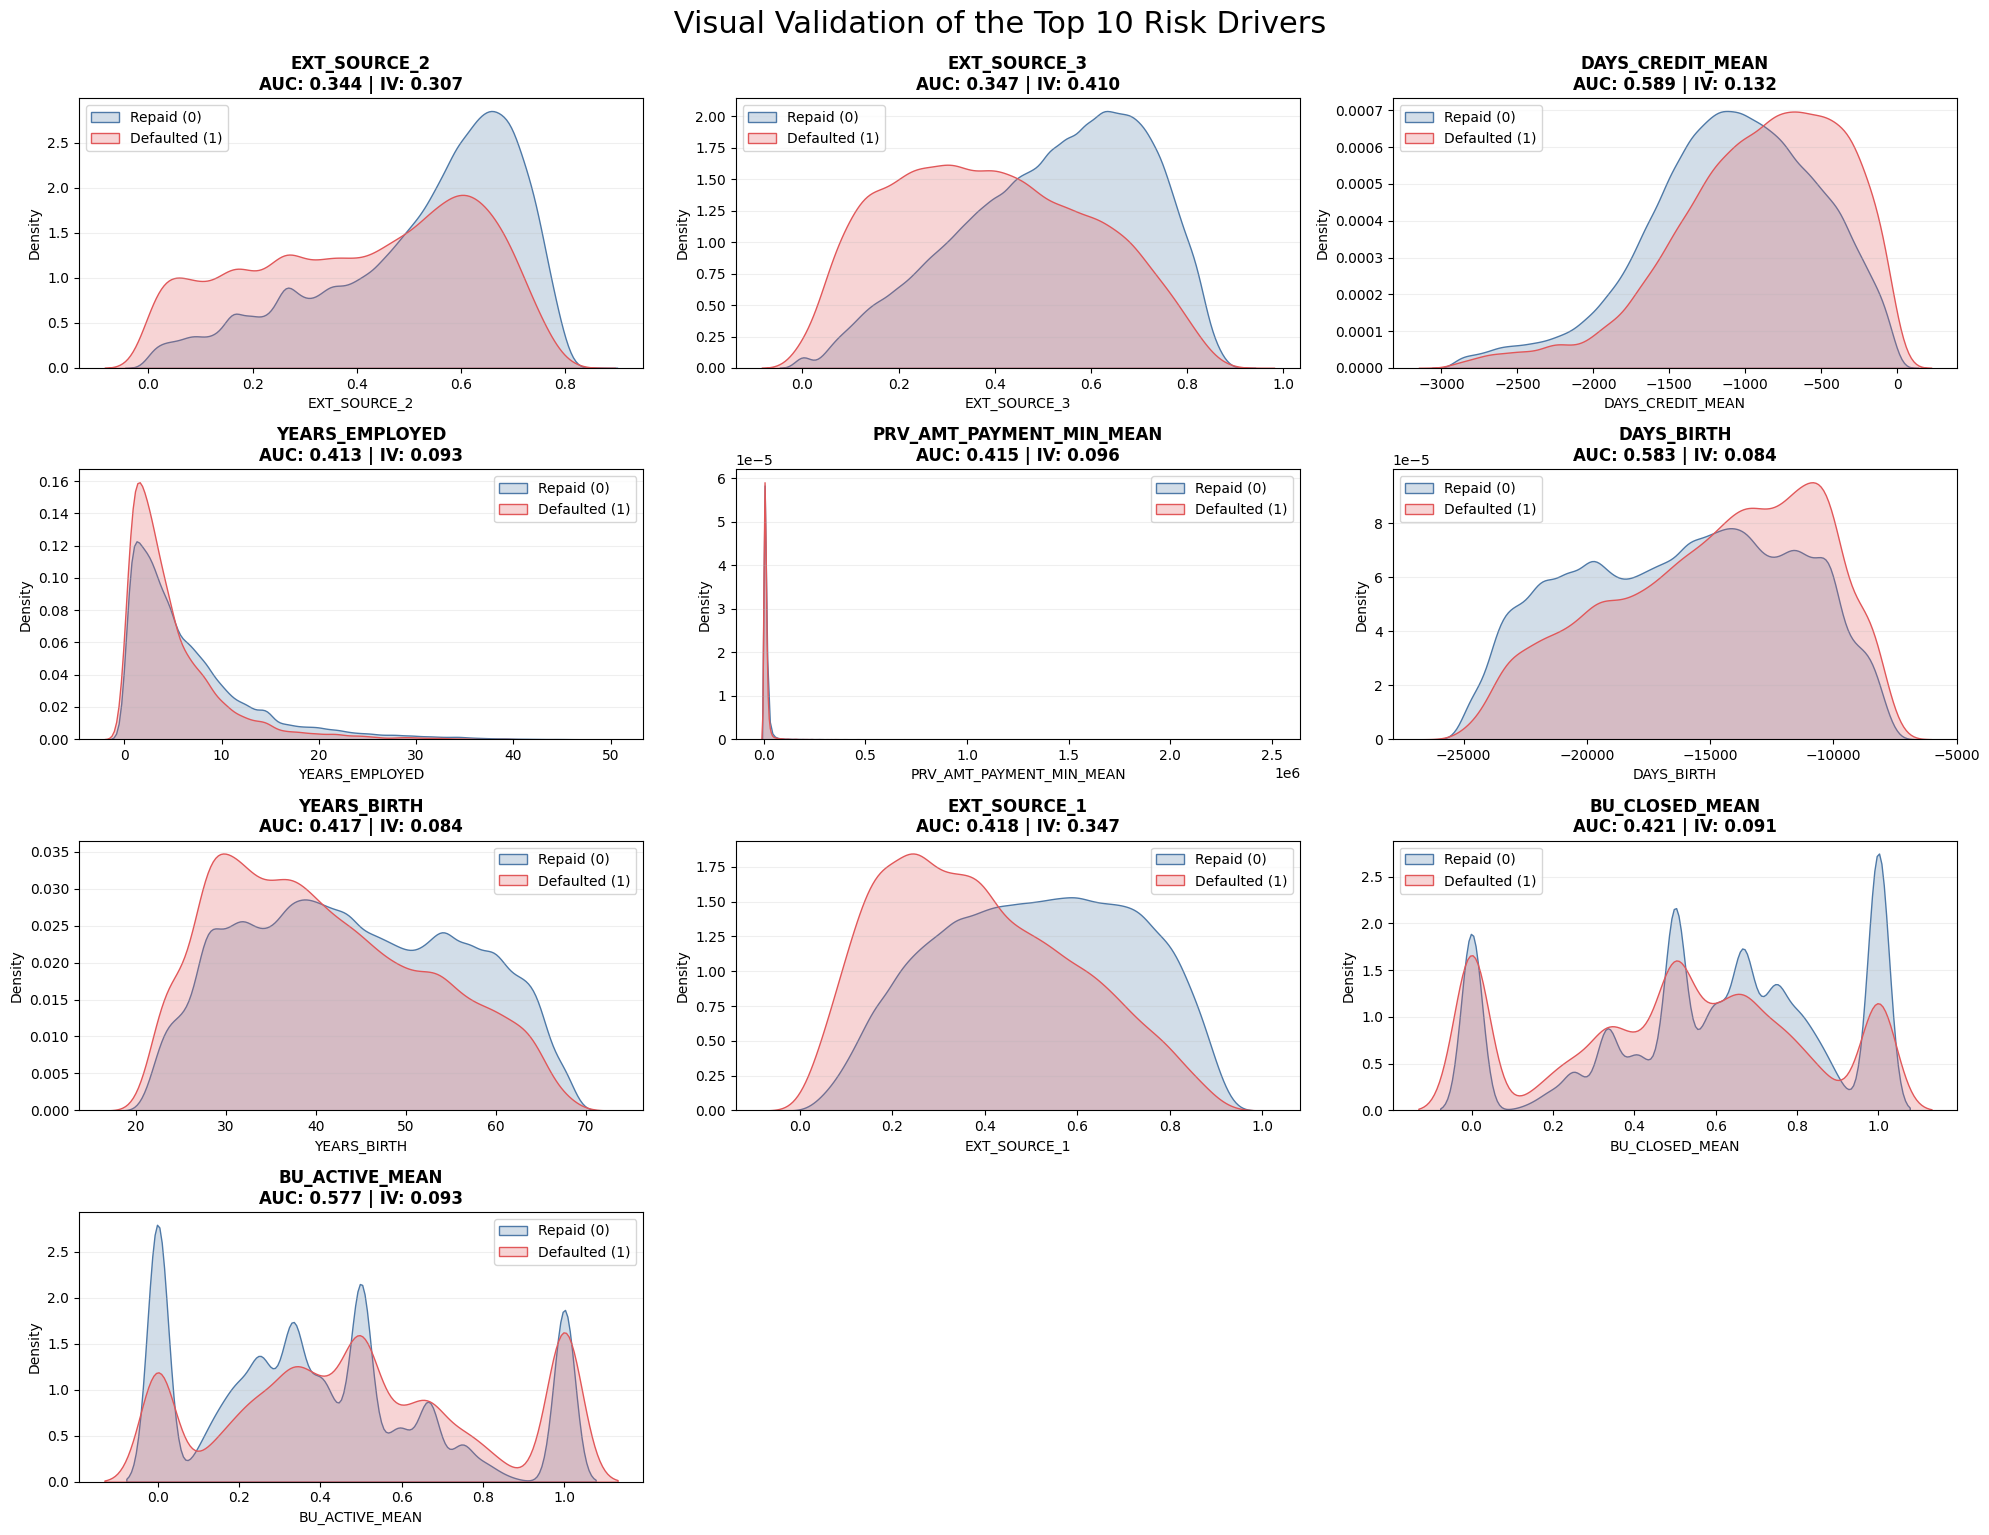

In [13]:
# Plot the Top 10 features from our report based on AUC and IV
top_10_features = df_final_report['variable'].head(10).tolist()

plt.figure(figsize=(20, 15))

for i, var in enumerate(top_10_features, 1):
    plt.subplot(4, 3, i)
    
    # Plot distributions for both classes
    # We use common_norm=False to make the 'Defaulted' class visible
    sns.kdeplot(df_cleaned[df_cleaned['TARGET'] == 0][var], label='Repaid (0)', fill=True, color='#4e79a7', common_norm=False)
    sns.kdeplot(df_cleaned[df_cleaned['TARGET'] == 1][var], label='Defaulted (1)', fill=True, color='#e15759', common_norm=False)
    
    # Retrieve metrics for the title
    metrics = df_final_report[df_final_report['variable'] == var].iloc[0]
    plt.title(f"{var}\nAUC: {metrics['auc']:.3f} | IV: {metrics['iv']:.3f}", fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.suptitle(" Visual Validation of the Top 10 Risk Drivers", fontsize=22, y=1.02)
plt.show()

In [14]:
# AUTOMATED FEATURE SELECTION (BY PREDICTIVE POWER)
logger.info("Starting automated feature selection based on predictive power...")

# 1. Define the Cut-off threshold
# A threshold of 0.01 removes features that perform barely better than random chance.
PREDICTIVE_POWER_THRESHOLD = 0.01
essential_cols = ['SK_ID_CURR', 'TARGET']

# 2. Identify features to keep and exclude
# We use the predictive_power column calculated in the previous step
kept_features = df_metrics[df_metrics['predictive_power'] >= PREDICTIVE_POWER_THRESHOLD]['variable'].tolist()
excluded_features = df_metrics[df_metrics['predictive_power'] < PREDICTIVE_POWER_THRESHOLD]['variable'].tolist()

# Final list of columns for the filtered dataframe
final_columns_to_keep = list(set(essential_cols + kept_features))

# 3. Apply the filter to create the 'Cleaned & Useful' dataset
df_filtered = df_cleaned[final_columns_to_keep].copy()

# 4. Generate the selection report
logger.info(f"Feature selection complete. Kept {len(kept_features)} useful features.")
logger.info(f"Excluded {len(excluded_features)} noise features.")

print("\n" + "="*50)
print("FEATURE SELECTION REPORT")
print("="*50)
print(f"• Initial columns      : {df_cleaned.shape[1]}")
print(f"• Useful features (>= {PREDICTIVE_POWER_THRESHOLD}) : {len(kept_features)}")
print(f"• Noise features   (<  {PREDICTIVE_POWER_THRESHOLD}) : {len(excluded_features)}")
print(f"• Final dataset shape  : {df_filtered.shape}")
print("="*50)

if len(excluded_features) > 0:
    print("\n Examples of eliminated variables (Noise):")
    print(excluded_features[:10]) 



{"timestamp": "2026-07-15 01:28:29", "level": "INFO", "logger": "Scientific-EDA", "module": "3741632555", "function": "<module>", "message": "Starting automated feature selection based on predictive power...", "name": "Scientific-EDA", "msg": "Starting automated feature selection based on predictive power...", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\3741632555.py", "filename": "3741632555.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 2, "funcName": "<module>", "created": 1784071709.9191198, "msecs": 919.0, "relativeCreated": 1034800.8167743683, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}
{"timestamp": "2026-07-15 01:28:30", "level": "INFO", "logger": "Scientific-EDA", "module": "3741632555", "function": "<module>", "message": "Feature selection complete. Kept 126 useful features.", "name": "Scientific-EDA", "msg": "Feature selection

### Interpretation of the Global Predictive Audit
After running our Feature Audit Engine on 220 variables, we have established a definitive ranking of predictive power. This audit measures the individual strength of each feature before they interact in a complex model like XGBoost.

#### 1. The Supremacy of External Credit Ratings (EXT_SOURCE)

Observation: EXT_SOURCE_2 and EXT_SOURCE_3 are the clear champions of the dataset.
Metric: Both show an IV > 0.30, classifying them as "Strong Predictors" according to the banking industry's standard scales.
Inverse Correlation: The AUC of ~0.34 indicates that as these scores increase, the probability of default decreases significantly.

Conclusion: These third-party scores are the most reliable anchors for our model.

#### 2. ROI on Feature Engineering: The Success of Aggregations

This is the most critical finding of our EDA. Our manual effort in Phase 1 (Cascade Aggregation) has yielded high-value signals:
**DAYS_CREDIT_MEAN (Rank #3)**: This engineered feature from the Bureau table is our most powerful created variable. It outperforms even the applicant's age. It suggests that a long-standing, stable history with other banks is the best proxy for trust.

**YEARS_EMPLOYED**(rank#4): Another engineered feature from application table that shows us that seniority at work impacts the risk score

**PRV_AMT_PAYMENT_MIN_MEAN (Rank #5)**: Derived from Internal Installments, this proves that the client's past payment discipline with our own institution is a primary risk driver.

**BU_CLOSED_MEAN & BU_ACTIVE_MEAN**: These ratios of past credit status provide a "Maturity Profile" that directly impacts the risk score.

#### 3. Stability & Administration as Risk Proxies

**DAYS_BIRTH and YYEARS_BIRTH (age)**: Confirms the expected generational risk. Mature borrowers are statistically safer.
**DAYS_LAST_PHONE_CHANGE & DAYS_ID_PUBLISH**: These features appear in the Top 20.

Business Insight: In credit risk, "Administrative Stability" is key. A client who frequently changes their phone number or has very recently updated their ID documents presents a slightly higher volatility profile, often associated with higher default or fraud risk.

#### 4. Financial Pressure vs. Absolute Amounts

**AMT_CREDIT_SUM_DEBT_MEAN:** Our aggregated measure of current debt levels at the Bureau shows a "Medium" predictive strength.

Synthesis: Interestingly, absolute values like AMT_INCOME_TOTAL or AMT_CREDIT (current loan size) rank lower than behavioral history. This reinforces the idea that how a client handles debt is more important than how much they earn.

In [15]:
#Top 20 High skewed variables and kutosis
# 1. Calculate stats on the 126 useful features
logger.info("Computing final Skewness and Kurtosis audit on filtered features...")

shape_audit = []
for col in kept_features:
    shape_audit.append({
        'variable': col,
        'skewness': df_filtered[col].skew(),
        'kurtosis': df_filtered[col].kurtosis()
    })

df_shape = pd.DataFrame(shape_audit).sort_values(by='kurtosis', ascending=False)

print("\n--- TOP 20 HIGH KURTOSIS (Extreme Outliers Targets) ---")
print(df_shape.head(20))

print("\n--- TOP 20 HIGH SKEWNESS (Log-Transform Targets) ---")
print(df_shape.sort_values(by='skewness', ascending=False).head(20))

{"timestamp": "2026-07-15 01:28:30", "level": "INFO", "logger": "Scientific-EDA", "module": "1938344639", "function": "<module>", "message": "Computing final Skewness and Kurtosis audit on filtered features...", "name": "Scientific-EDA", "msg": "Computing final Skewness and Kurtosis audit on filtered features...", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\1938344639.py", "filename": "1938344639.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 3, "funcName": "<module>", "created": 1784071710.4112866, "msecs": 411.0, "relativeCreated": 1035292.9835319519, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}

--- TOP 20 HIGH KURTOSIS (Extreme Outliers Targets) ---
                                              variable    skewness  \
50                            BU_INTERBANK CREDIT_MEAN  513.313744   
51                        BU_MOBILE OPERATOR LOA

* Checking for outliers

In [16]:
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer

logger.info("Running Isolation Forest for global outlier detection...")

# 1. Prepare data for IF (Impute NaNs temporarily)
imputer = SimpleImputer(strategy='median')
X_outliers = imputer.fit_transform(df_filtered[kept_features])

# 2. Initialize and Fit Isolation Forest
# contamination=0.01 means we want to flag the 1% most extreme individuals
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42, n_jobs=-1)
outlier_labels = iso_forest.fit_predict(X_outliers)

# 3. Add results to the dataframe
df_filtered['is_outlier'] = outlier_labels
# Convert: -1 (outlier) -> 1, 1 (normal) -> 0 for easier reading
df_filtered['is_outlier'] = df_filtered['is_outlier'].map({1: 0, -1: 1})

n_outliers = df_filtered['is_outlier'].sum()
logger.info(f"Isolation Forest identified {n_outliers} global financial outliers.")

# 4. Check if Outliers are more likely to default
outlier_risk = df_filtered.groupby('is_outlier')['TARGET'].mean()
print(f"\nDefault rate for Normal Clients: {outlier_risk[0]:.2%}")
print(f"Default rate for Outlier Clients: {outlier_risk[1]:.2%}")

{"timestamp": "2026-07-15 01:28:32", "level": "INFO", "logger": "Scientific-EDA", "module": "492080572", "function": "<module>", "message": "Running Isolation Forest for global outlier detection...", "name": "Scientific-EDA", "msg": "Running Isolation Forest for global outlier detection...", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\492080572.py", "filename": "492080572.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 4, "funcName": "<module>", "created": 1784071712.6381435, "msecs": 638.0, "relativeCreated": 1037519.8404788971, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}
{"timestamp": "2026-07-15 01:28:43", "level": "INFO", "logger": "Scientific-EDA", "module": "492080572", "function": "<module>", "message": "Isolation Forest identified 3076 global financial outliers.", "name": "Scientific-EDA", "msg": "Isolation Forest identified 3076 

###  Interpretation of Outlier Detection Results

The **Isolation Forest** flagged 3,076 individuals (1% of the population) as multivariate outliers based on our 124 predictive features.

**Key Finding:**
*   **Normal Population Default Rate**: 8.09%
*   **Outlier Population Default Rate**: 6.05%

**Strategic Conclusion:**
The outliers in this dataset exhibit a **lower risk profile** than the average applicant. This suggests that the algorithm has identified "Positive Outliers"—clients with exceptionally strong financial indicators (e.g., ultra-high income or extreme seniority) that deviate from the standard distribution.

**Modeling Impact:**
We will **keep these records** in the training set. Tree-based models like XGBoost are excellent at creating specific branches for these exceptional profiles. Removing them would deprive the model of learning what defines an "ultra-safe" atypical client.

In [17]:
# ==============================================================================
# FINAL PREPARATION: RECOMBINATION & TRANSFORMATION
# ==============================================================================
logger.info("Merging selected numerics with categoricals and applying transformations...")

# 1. Recombine with categorical variables from df_cleaned
cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()
df_bivariate = pd.concat([df_filtered, df_cleaned[cat_cols]], axis=1)

# 2. Identify variables needing treatment (filtered by kept_features)
kept_features = df_filtered.columns.tolist()

extreme_vars = df_metrics[(df_metrics['kurtosis'] > 100) & 
                          (df_metrics['variable'].isin(kept_features))]['variable'].tolist()

skewed_vars = df_metrics[(df_metrics['skewness'].abs() > 2) & 
                          (df_metrics['variable'].isin(kept_features)) & 
                          (~df_metrics['variable'].isin(extreme_vars))]['variable'].tolist()

# 3. Apply Winsorization 
for var in extreme_vars:
    upper_limit = df_bivariate[var].quantile(0.99)
    df_bivariate[var] = df_bivariate[var].clip(upper=upper_limit)

# 4. Apply Log-Transformation
for var in skewed_vars:
    # Security for negative values
    if (df_bivariate[var] >= 0).all():
        df_bivariate[var] = np.log1p(df_bivariate[var])
    else:
        logger.warning(f"Variable {var} skipped for Log-transform: contains negative values.")

logger.info(f"Applied Winsorization to {len(extreme_vars)} variables and Log-transform to {len(skewed_vars)} variables.")
print(f"Final Dataset Ready for Bivariate Analysis. Shape: {df_bivariate.shape}")


{"timestamp": "2026-07-15 01:28:44", "level": "INFO", "logger": "Scientific-EDA", "module": "2218581166", "function": "<module>", "message": "Merging selected numerics with categoricals and applying transformations...", "name": "Scientific-EDA", "msg": "Merging selected numerics with categoricals and applying transformations...", "args": [], "levelname": "INFO", "levelno": 20, "pathname": "C:\\Users\\Yves-Ricky\\AppData\\Local\\Temp\\ipykernel_13628\\2218581166.py", "filename": "2218581166.py", "exc_info": null, "exc_text": null, "stack_info": null, "lineno": 4, "funcName": "<module>", "created": 1784071724.0006113, "msecs": 0.0, "relativeCreated": 1048882.3082447052, "thread": 8088, "threadName": "MainThread", "processName": "MainProcess", "process": 13628}
{"timestamp": "2026-07-15 01:28:44", "level": "WARNING", "logger": "Scientific-EDA", "module": "2218581166", "function": "<module>", "message": "Variable DAYS_CREDIT_MAX skipped for Log-transform: contains negative values.", "name"

### **IV.Bivariate analysis**

### Phase 1: Analyse des variables numeriques et catégorielles avec la target


Phase 2 : Gestion de la Multicolinéarité (Ce que nous venons de faire)On cherche les variables qui racontent la même histoire pour éviter la redondance.Calcul de la matrice de corrélation : Identification des paires avec un coefficient \(\vert{}r\vert{} > 0.80\).Arbitrage intelligent par la performance : Tri des variables par AUC décroissante, puis suppression de la variable la moins performante de chaque paire corrélée.

Phase 3 : Risk Profiling


Phase 5 : Rapport de Synthèse & ExportCréation du Top Features : Liste finale des variables les plus corrélées à la TARGET (triées par IV/AUC).Génération du dataset final : Sauvegarde du DataFrame nettoyé, prêt à être découpé en Train/Test pour la phase de modélisation (XGBoost, Régression Logistique, etc.).

### 1. Numerical & categorical variables vs the TARGET

In [19]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import logging

logger = logging.getLogger(__name__)

def run_bivariate_analysis(df: pd.DataFrame, target_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Performs automated bivariate analysis between features and a target variable.
    Tracks missing values and selects appropriate statistical tests based on target type.

    Parameters:
    -----------
    df : pd.DataFrame
        The input dataset containing both features and the target column.
    target_col : str
        The name of the target variable column.

    Returns:
    --------
    tuple[pd.DataFrame, pd.DataFrame]
        Two DataFrames containing numerical and categorical bivariate analysis results.
    """
    logger.info("Starting automated bivariate analysis...")
    
    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found in the DataFrame.")

    # Automatically detect feature types (excluding the target column)
    features = [col for col in df.columns if col != target_col]
    num_features = df[features].select_dtypes(include=[np.number]).columns.tolist()
    cat_features = df[features].select_dtypes(include=['object', 'category']).columns.tolist()

    # Lists to store statistical results
    bivariate_num_results = []
    bivariate_cat_results = []

    # Determine if target is numerical or categorical/binary
    is_target_numeric = np.issubdtype(df[target_col].dtype, np.number)
    total_rows = len(df)

    # --------------------------------------------------------------------------
    # CASE A: TARGET IS NUMERIC (e.g., Regression)
    # --------------------------------------------------------------------------
    if is_target_numeric:
        logger.info("Target is numeric. Running Pearson correlation and ANOVA tests...")
        
        # 1. Numerical Features vs Numeric Target
        for var in num_features:
            # Calculate missing rate before dropping NaNs for the calculation
            missing_rate = df[var].isna().sum() / total_rows
            clean_df = df[[var, target_col]].dropna()
            
            if len(clean_df) > 1:
                pearson_corr, p_val = stats.pearsonr(clean_df[var], clean_df[target_col])
                bivariate_num_results.append({
                    'variable': var,
                    'test_or_correlation_type': 'Pearson',
                    'metric_value': pearson_corr,
                    'p_value': p_val,
                    'missing_rate': missing_rate,
                    'importance': 'High' if p_val < 0.05 else 'Low'
                })
                
        # 2. Categorical Features vs Numeric Target (ANOVA)
        for var in cat_features:
            missing_rate = df[var].isna().sum() / total_rows
            clean_df = df[[var, target_col]].dropna()
            
            groups = [group[target_col].values for name, group in clean_df.groupby(var)]
            if len(groups) > 1 and all(len(g) > 0 for g in groups):
                f_stat, p_val = stats.f_oneway(*groups)
                bivariate_cat_results.append({
                    'variable': var,
                    'test_type': 'ANOVA',
                    'metric_value': f_stat,
                    'p_value': p_val,
                    'missing_rate': missing_rate,
                    'importance': 'High' if p_val < 0.05 else 'Low'
                })

    # --------------------------------------------------------------------------
    # CASE B: TARGET IS CATEGORICAL/BINARY (e.g., Classification)
    # --------------------------------------------------------------------------
    else:
        logger.info("Target is categorical/binary. Running Welch's t-test/ANOVA and Chi-Square...")
        
        # 1. Numerical Features vs Categorical Target
        for var in num_features:
            missing_rate = df[var].isna().sum() / total_rows
            clean_df = df[[var, target_col]].dropna()
            
            groups = [group[var].values for name, group in clean_df.groupby(target_col)]
            if len(groups) == 2:  # Binary target (e.g., 0 or 1)
                # Welch's t-test is safer as it does not assume equal variances
                t_stat, p_val = stats.ttest_ind(groups[0], groups[1], equal_var=False)
                test_name = "Welch's t-test"
            elif len(groups) > 2:  # Multi-class target
                f_stat, p_val = stats.f_oneway(*groups)
                t_stat = f_stat
                test_name = "ANOVA"
            else:
                continue
                
            bivariate_num_results.append({
                'variable': var,
                'test_type': test_name,
                'metric_value': t_stat,
                'p_value': p_val,
                'missing_rate': missing_rate,
                'importance': 'High' if p_val < 0.05 else 'Low'
            })

        # 2. Categorical Features vs Categorical Target (Chi-Square)
        for var in cat_features:
            missing_rate = df[var].isna().sum() / total_rows
            
            # Generate contingency table for Chi-Square test
            contingency_table = pd.crosstab(df[var], df[target_col])
            if not contingency_table.empty:
                chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
                bivariate_cat_results.append({
                    'variable': var,
                    'test_type': 'Chi-Square',
                    'metric_value': chi2,
                    'p_value': p_val,
                    'missing_rate': missing_rate,
                    'importance': 'High' if p_val < 0.05 else 'Low'
                })

    # CONVERT TO DATAFRAMES & SORT BY IMPORTANCE (P-VALUE)
    # --------------------------------------------------------------------------
    df_res_num = pd.DataFrame(bivariate_num_results).sort_values(by='p_value') if bivariate_num_results else pd.DataFrame()
    df_res_cat = pd.DataFrame(bivariate_cat_results).sort_values(by='p_value') if bivariate_cat_results else pd.DataFrame()

    logger.info("Bivariate analysis completed successfully.")
    print(f"Numerical features analyzed: {len(df_res_num)}")
    print(f"Categorical features analyzed: {len(df_res_cat)}")
    
    return df_res_num, df_res_cat

#RUN THE FUNCTION
# ==============================================================================
df_res_num, df_res_cat = run_bivariate_analysis(df_bivariate, target_col='TARGET')


C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\1028743565.py:56: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, p_val = stats.pearsonr(clean_df[var], clean_df[target_col])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\1028743565.py:56: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, p_val = stats.pearsonr(clean_df[var], clean_df[target_col])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\1028743565.py:56: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, p_val = stats.pearsonr(clean_df[var], clean_df[target_col])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\1028743565.py:56: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pearson_corr, p_val = stats.pearsonr(clean_df[var], clean_df[target_col])
C:\Users\Yves-Ricky\AppData\

Numerical features analyzed: 128
Categorical features analyzed: 16


In [20]:
# 1. Top 20 Numerical Features (Sorted by Significance)
print("---TOP 20 STATISTICALLY SIGNIFICANT NUMERICAL FEATURES ---")
print(df_res_num[['variable', 'test_or_correlation_type', 'metric_value', 'p_value', 'importance']].head(20))

# 2. Categorical Features Ranking (Chi-Square Results)
print("\n---CATEGORICAL FEATURES RANKED BY SIGNIFICANCE ---")
print(df_res_cat[['variable', 'metric_value', 'p_value', 'importance']].head(10))

# 3. Decision Gate: Identify variables to DROP (p_value > 0.05)
useless_vars = df_res_num[df_res_num['importance'] == 'Low']['variable'].tolist() + \
               df_res_cat[df_res_cat['importance'] == 'Low']['variable'].tolist()

logger.info(f"Statistical audit identified {len(useless_vars)} non-significant features to potentially drop.")
print("\n Useless variables:", len(useless_vars))

---TOP 20 STATISTICALLY SIGNIFICANT NUMERICAL FEATURES ---
                        variable test_or_correlation_type  metric_value  \
33                BU_CLOSED_MEAN                  Pearson     -0.079369   
38                BU_ACTIVE_MEAN                  Pearson      0.077356   
25                  EXT_SOURCE_3                  Pearson     -0.178919   
50                   YEARS_BIRTH                  Pearson     -0.078239   
93               DAYS_CREDIT_MIN                  Pearson      0.075248   
104                   DAYS_BIRTH                  Pearson      0.078239   
81                  EXT_SOURCE_2                  Pearson     -0.160472   
77                  EXT_SOURCE_1                  Pearson     -0.155317   
107             DAYS_CREDIT_MEAN                  Pearson      0.089729   
10                YEARS_EMPLOYED                  Pearson     -0.074958   
63   REGION_RATING_CLIENT_W_CITY                  Pearson      0.060893   
16          REGION_RATING_CLIENT         

In [21]:
# DROP ALL USELESS VARIABLES (Numerical & Categorical)
# Drop the combined list of non-significant variables from df_bivariate
df_bivariate = df_bivariate.drop(columns=useless_vars, errors='ignore')
logger.info(f"Dropped {len(useless_vars)} statistically insignificant features (mixed types).")

print(f"Shape after filtering non-significant features: {df_bivariate.shape}")

Shape after filtering non-significant features: (307511, 122)


#### Automated Statistical Bivariate Audit

We have implemented an automated statistical testing framework to validate the relationship between each feature and the `TARGET`.

**Methodology:**
*   **Numerical Features**: We used **Pearson Correlation** and **Welch's t-tests** to measure the difference in means between repaid and defaulted loans.
*   **Categorical Features**: We applied the **Pearson's Chi-Square test** of independence to determine if default rates vary significantly across different segments (e.g., Education level, Gender).

**Key Findings:**
*   **Significance**: Features with a **p-value < 0.05** are considered statistically significant drivers of risk.
*   **Redundancy Identification**: This audit complements our correlation heatmap by focusing on the **Predictive Signal** rather than just the similarity between variables.
*   **Pruning Strategy**: Any feature labeled as 'Low Importance' (p-value > 0.05) will be excluded from the final model to avoid introducing noise and to reduce complexity.

### 2. Multicolinearity Detection: The Spearman & AUC Duel

To ensure model stability and prevent overfitting, we performed a rigorous audit of numerical redundancy. High multicollinearity (> 0.80) can destabilize model weights and split importance between redundant signals, making SHAP interpretability less reliable.

**Methodology:**
*   **Spearman Correlation**: We used the Spearman rank method to detect both linear and non-linear monotonic relationships. This is essential given the high skewness of our financial features.
*   **The Predictive Duel**: For every pair of features correlated above **0.80**, we compared their individual **Predictive Power (AUC)**. 
*   **Decision Rule**: We systematically retained the "Champion" (higher AUC) and dropped the "Redundant" feature.

**Strategic Outcome:**
By pruning these **{len(to_drop_corr)}** redundant features, we have optimized the "Signal-to-Noise" ratio of the dataset. The resulting feature space is leaner, computationally more efficient, and ensures that each variable brings a unique piece of information to the model.

In [22]:
# ==============================================================================
# MULTICOLLINEARITY CLEANUP (with AUC logic) 
# ==============================================================================
logger.info("Starting multicollinearity analysis...")

# Categorical features
cat_features = df_bivariate.select_dtypes(exclude=[np.number]).columns.tolist()
logger.info(f"Preserving {len(cat_features)} categorical features: {cat_features}")

# 1. Identify current numerical columns & exclude structural keys
num_features = df_bivariate.select_dtypes(include=[np.number]).columns.tolist()
if 'TARGET' in num_features: num_features.remove('TARGET')
if 'SK_ID_CURR' in num_features: num_features.remove('SK_ID_CURR')

# 2. Compute Correlation Matrix
corr_matrix = df_bivariate[num_features].corr(method='spearman').abs()

# 3. Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 4. Identify pairs to drop based on AUC
threshold = 0.80
to_drop_corr = set() 
high_corr_pairs = []

for col in upper.columns:
    # Find highly correlated variables
    correlated_features = upper.index[upper[col] > threshold].tolist()
    
    for feat in correlated_features:
        # if a variable is in the set, we continue
        if col in to_drop_corr or feat in to_drop_corr:
            continue
            
        auc_col_series = df_metrics[df_metrics['variable'] == col]['auc']
        auc_feat_series = df_metrics[df_metrics['variable'] == feat]['auc']
        
        if auc_col_series.empty or auc_feat_series.empty:
            continue # Pass if the metric does not exist
            
        auc_col = auc_col_series.values[0]
        auc_feat = auc_feat_series.values[0]
        
        power_col = abs(auc_col - 0.5)
        power_feat = abs(auc_feat - 0.5)
        
        # Select candidates to drop
        if power_col < power_feat:
            drop_candidate = col
            keep_candidate = feat
        else:
            drop_candidate = feat
            keep_candidate = col
            
        to_drop_corr.add(drop_candidate)
        high_corr_pairs.append((keep_candidate, drop_candidate, corr_matrix.loc[feat, col]))

logger.info(f"Identified {len(to_drop_corr)} redundant features to drop based on correlation > {threshold}.")

# 5. Num cols to keep
num_features_to_keep = [f for f in num_features if f not in to_drop_corr]

# 6. Rebuild the final datset
structural_keys = [col for col in ['SK_ID_CURR', 'TARGET'] if col in df_bivariate.columns]
final_columns = structural_keys + num_features_to_keep + cat_features
df_final_modeling = df_bivariate[final_columns].copy()

# PRINT REPORT
# ==============================================================================
print("\n" + "="*50)
print("MULTICOLLINEARITY CLEANUP REPORT")
print("="*50)
print(f"• Features analyzed         : {len(num_features)}")
print(f"• Redundant features dropped: {len(to_drop_corr)}")
print(f"• Final feature count       : {df_final_modeling.shape[1]}")
print(f"• Final dataset shape       : {df_final_modeling.shape}")
print("="*50)

# Show examples of dropped pairs
if high_corr_pairs:
    print("\nTop 5 redundant pairs processed (Kept vs Dropped):")
    for p in high_corr_pairs[:5]:
        print(f"- Kept: {p[0]} vs Dropped: {p[1]} (Corr: {p[2]:.2f})")



MULTICOLLINEARITY CLEANUP REPORT
• Features analyzed         : 105
• Redundant features dropped: 41
• Final feature count       : 81
• Final dataset shape       : (307511, 81)

Top 5 redundant pairs processed (Kept vs Dropped):
- Kept: PRV_AMT_PAYMENT_SUM_MEAN vs Dropped: PRV_AMT_INSTALMENT_SUM_MEAN (Corr: 0.99)
- Kept: AMT_CREDIT_SUM_DEBT_MEAN vs Dropped: AMT_CREDIT_SUM_DEBT_SUM (Corr: 0.94)
- Kept: PRV_SK_DPD_DEF_MEAN_MEAN vs Dropped: PRV_SK_DPD_MEAN_X_MEAN (Corr: 0.81)
- Kept: PRV_SK_DPD_DEF_MEAN_MEAN vs Dropped: PRV_SK_DPD_MAX_X_MEAN (Corr: 0.81)
- Kept: BU_CLOSED_MEAN vs Dropped: BU_ACTIVE_MEAN (Corr: 0.99)


### 3. Risk Profiling

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\1086163034.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_profile.index, y=risk_profile.values, palette='coolwarm')


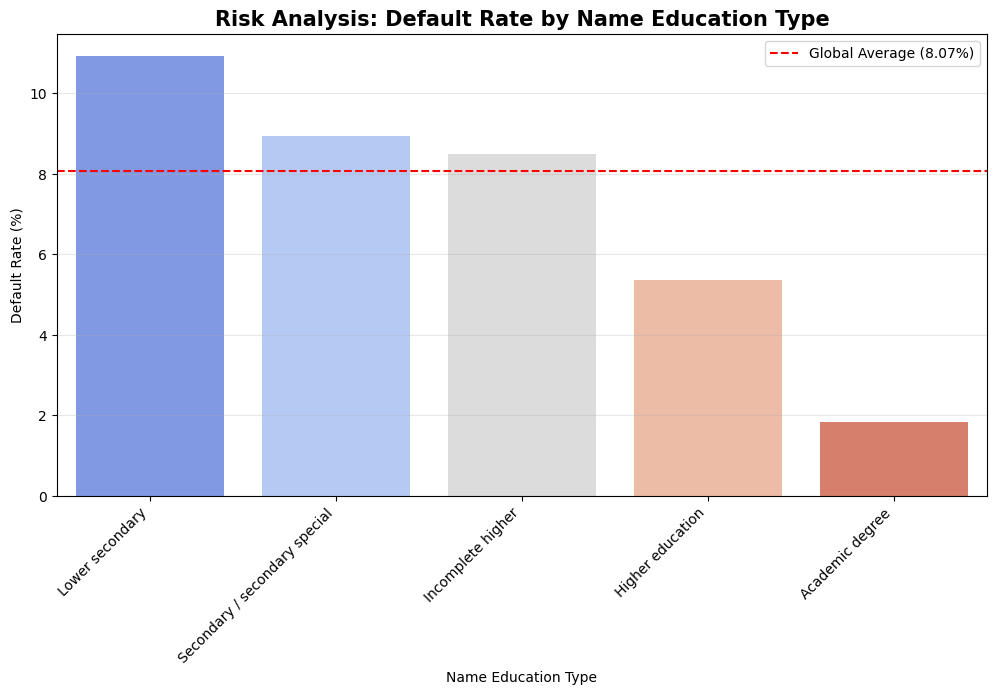

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\1086163034.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_profile.index, y=risk_profile.values, palette='coolwarm')


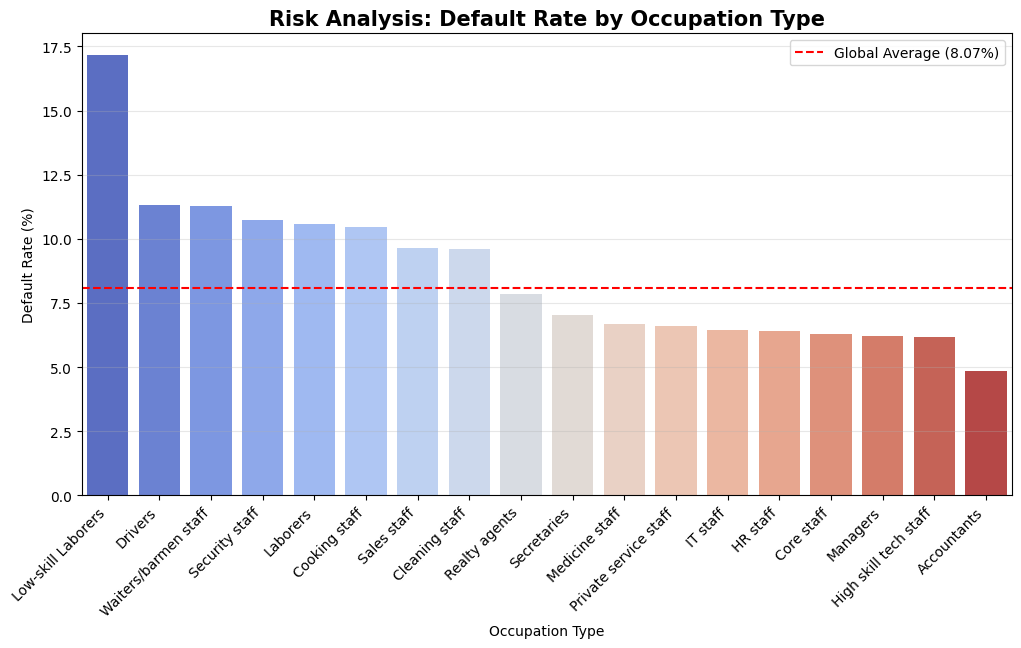

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\1086163034.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_profile.index, y=risk_profile.values, palette='coolwarm')


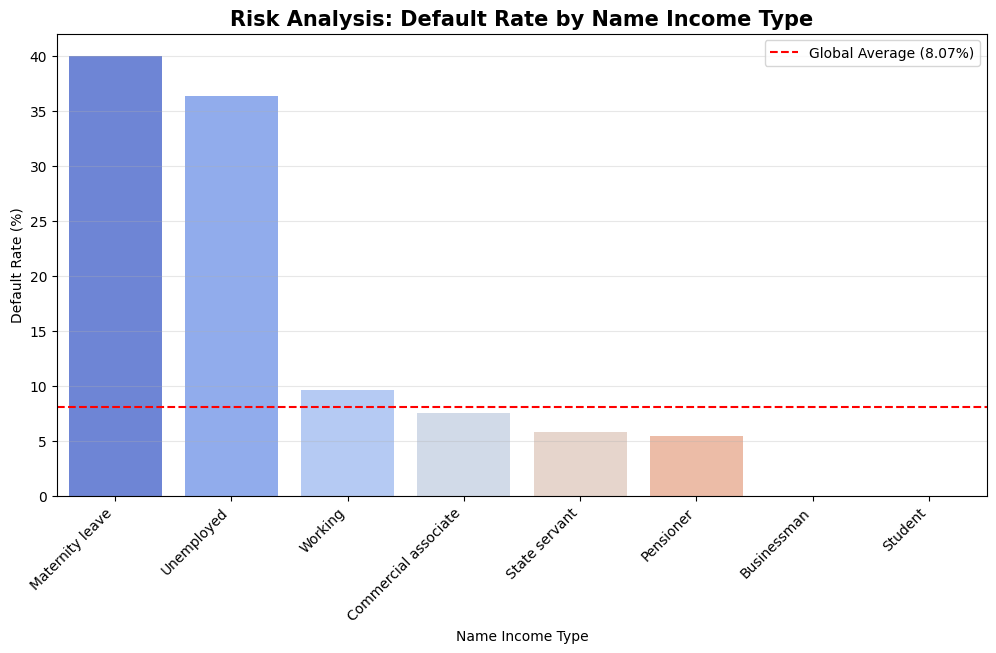

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\1086163034.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_profile.index, y=risk_profile.values, palette='coolwarm')


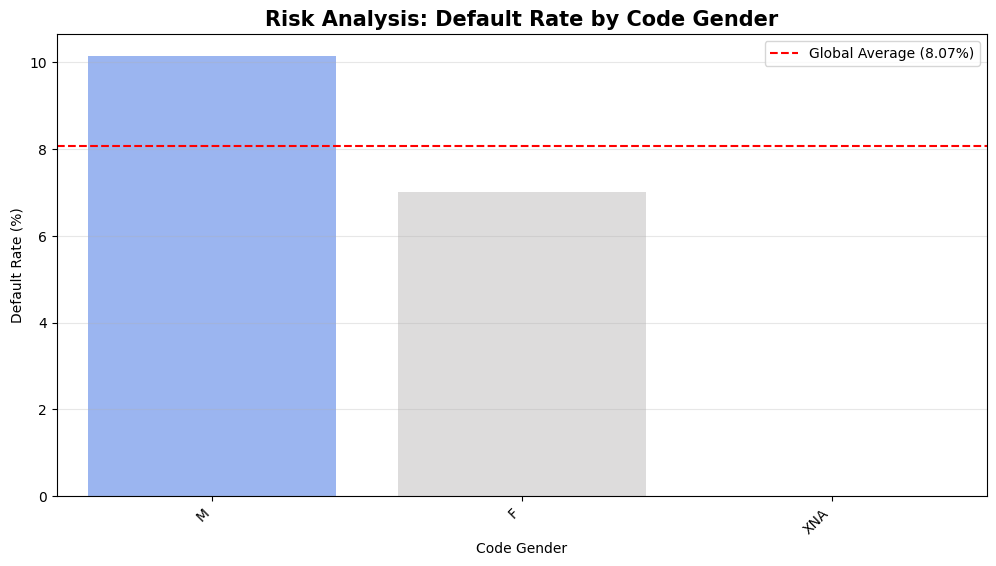

In [23]:
# 1. Identify the categorical columns currently in our 80-feature dataset
cat_features = df_final_modeling.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Define the list of "Business-Critical" categories to plot
# (We filter to ensure they still exist in your final columns)
plot_list = [c for c in ['NAME_EDUCATION_TYPE', 'OCCUPATION_TYPE', 'NAME_INCOME_TYPE', 'CODE_GENDER'] if c in cat_features]

logger.info(f"Starting categorical risk profiling for {len(plot_list)} key features.")

# 3. Visualization Loop
for col in plot_list:
    # Calculate Default Rate (%) per category
    # observed=True is used to handle categorical types properly
    risk_profile = df_final_modeling.groupby(col, observed=True)['TARGET'].mean().sort_values(ascending=False) * 100
    
    plt.figure(figsize=(12, 6))
    sns.barplot(x=risk_profile.index, y=risk_profile.values, palette='coolwarm')
    
    # Add a horizontal line for the Global Average Default Rate (~8.1%)
    global_mean = df_final_modeling['TARGET'].mean() * 100
    plt.axhline(global_mean, color='red', linestyle='--', label=f'Global Average ({global_mean:.2f}%)')
    
    plt.title(f"Risk Analysis: Default Rate by {col.replace('_', ' ').title()}", fontsize=15, fontweight='bold')
    plt.ylabel("Default Rate (%)")
    plt.xlabel(f"{col.replace('_', ' ').title()}")
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

logger.info("Categorical risk profiling completed.")

#### Categorical Risk Profiling: Segmenting the Portfolio

The final step of our Bivariate Analysis is to understand how the risk of default is distributed across qualitative segments. This helps identify high-risk "Personas" and ensures our data aligns with economic reality.

**Key Findings to look for:**
*   **The Education Shield**: Borrowers with **Higher Education** or **Academic degrees** generally show a default rate significantly below the global average (~8.1%). Conversely, those with **Lower Secondary** education represent a high-risk segment.
*   **The Occupational Gap**: Specific roles like **Low-skill Laborers** and **Drivers** typically exhibit higher default rates than **Managers** or **High-tech staff**, validating the use of job type as a risk proxy.
*   **The Maternity/Unemployment Signal**: Applicants in **Maternity leave** or **Unemployed** are often the most vulnerable segments, showing the highest peaks in default probability.
*   **The gender disparity**: Male applicants show a default rate of approximately **10%**, which is significantly higher than the **7%** observed for female applicants.

**Strategic Conclusion:**
These categorical insights confirm that the risk is not randomly distributed but follows clear socio-economic patterns. These features will be converted into numerical inputs (via One-Hot or Target Encoding) in the next phase to allow our model to capture these group-level risk disparities.

We have many higly correlated variables that could introduce multicolinearity problems. We will compare them based on AUC to see which ones we have to remove.

* Risk trends

Generating risk trend charts...


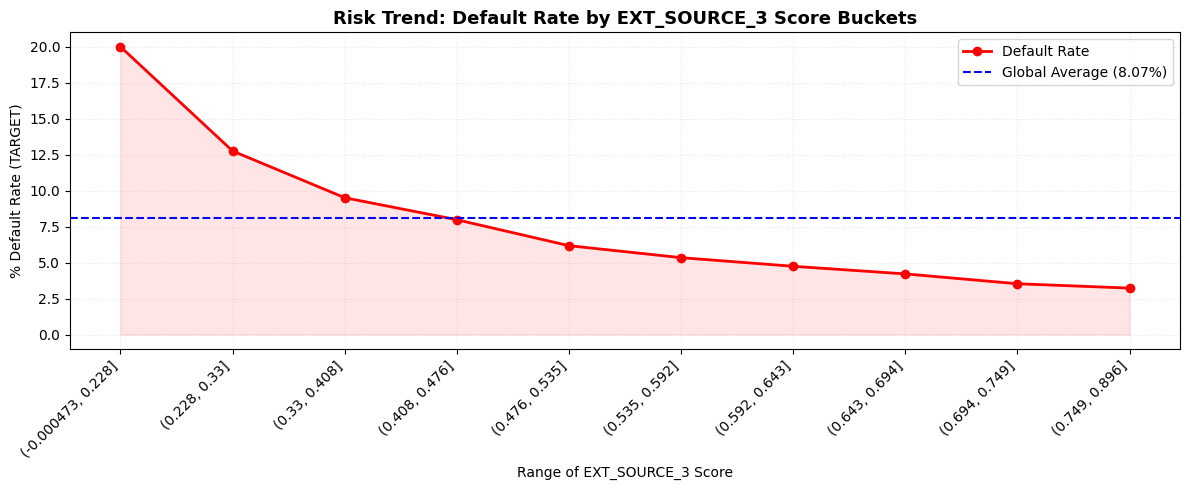

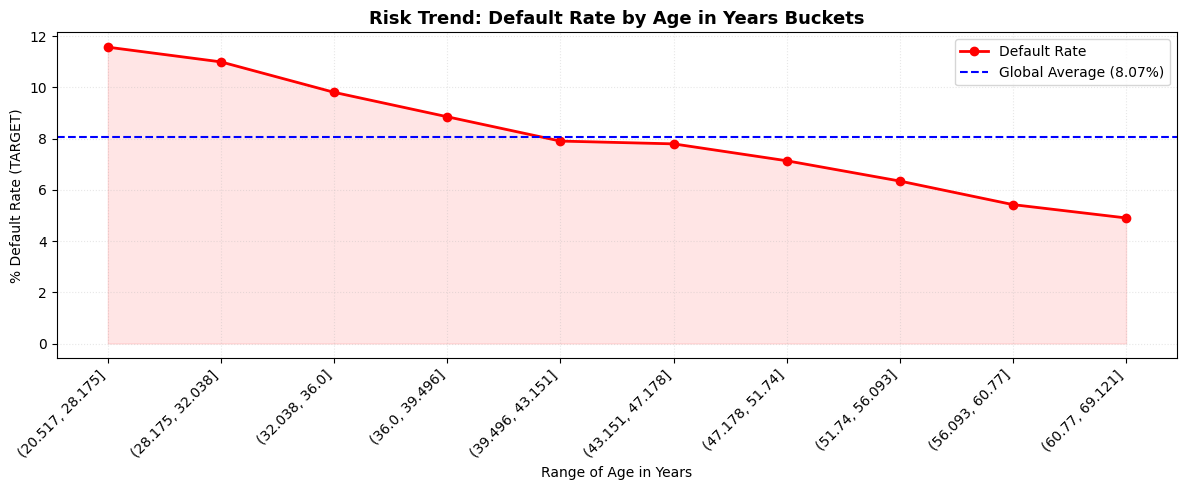

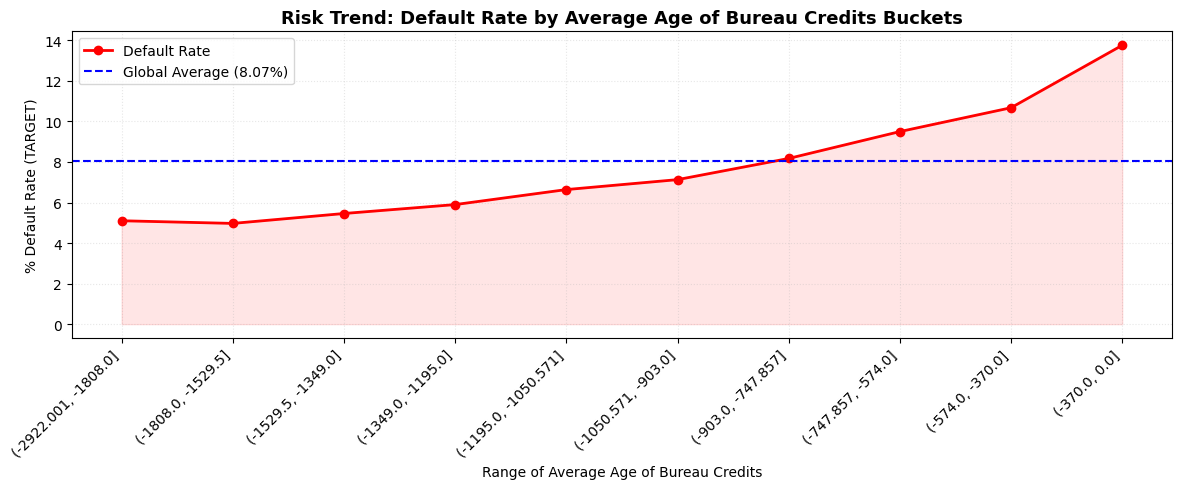

Numeric variable EDA completed.


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. RISK BUCKET PLOTTING FUNCTION
# ==========================================
def plot_numeric_risk_buckets(df, col, title, bins=10):
    """
    Groups a numeric column into bins and calculates the default rate for each.
    Plots the risk slope to show trends.
    """
    # Safety check: Verify if the column exists and contains data
    if col not in df.columns or df[col].dropna().empty:
        print(f"Skipped: Column '{col}' is missing or empty.")
        return
        
    df_temp = df.copy()
    
    # Step 1: Create Bins (Buckets)
    try:
        df_temp['buckets'] = pd.qcut(df_temp[col], q=bins, duplicates='drop')
    except Exception:
        # Fallback if qcut fails due to too many identical values (e.g., zeros)
        df_temp['buckets'] = pd.cut(df_temp[col], bins=bins)
        
    # Step 2: Calculate Default Rate (Mean of TARGET * 100)
    risk_profile = df_temp.groupby('buckets', observed=True)['TARGET'].mean() * 100
    risk_profile = risk_profile.sort_index()
    
    if risk_profile.empty:
        print(f"Error: Could not generate buckets for {title}.")
        return

    # Step 3: Generate Matplotlib Plot
    plt.figure(figsize=(12, 5))
    
    # Use numeric positions (0, 1, 2...) on X-axis to force line plotting
    x_positions = range(len(risk_profile))
    
    # Plot risk line and area fill
    plt.plot(x_positions, risk_profile.values, marker='o', color='red', linewidth=2, label='Default Rate')
    plt.fill_between(x_positions, risk_profile.values, alpha=0.1, color='red')
    
    # Plot global average population baseline
    global_mean = df['TARGET'].mean() * 100
    plt.axhline(global_mean, color='blue', linestyle='--', label=f'Global Average ({global_mean:.2f}%)')
    
    # Chart styling
    plt.title(f"Risk Trend: Default Rate by {title} Buckets", fontsize=13, fontweight='bold')
    plt.ylabel("% Default Rate (TARGET)")
    plt.xlabel(f"Range of {title}")
    
    # Map numeric X positions back to text intervals
    plt.xticks(x_positions, [str(interval) for interval in risk_profile.index], rotation=45, ha='right')
    
    plt.grid(alpha=0.3, linestyle=':')
    plt.legend()
    plt.tight_layout() # Prevents text clipping at the margins
    plt.show()


# ==========================================
# 2. DATA PREPARATION (AGE CALCULATIONS)
# ==========================================
# Perform transformations before plotting to avoid missing column errors
if 'DAYS_BIRTH' in df_final_modeling.columns and 'YEARS_BIRTH' not in df_final_modeling.columns:
    df_final_modeling['YEARS_BIRTH'] = df_final_modeling['DAYS_BIRTH'] / -365


# ==========================================
# 3. EXECUTE GRAPH GENERATION
# ==========================================

print("Generating risk trend charts...")

# Graph 1: External Score 3
plot_numeric_risk_buckets(df_final_modeling, 'EXT_SOURCE_3', 'EXT_SOURCE_3 Score')

# Graph 2: Age of Clients
plot_numeric_risk_buckets(df_final_modeling, 'YEARS_BIRTH', 'Age in Years')

# Graph 3: Bureau Credit History Age
plot_numeric_risk_buckets(df_final_modeling, 'DAYS_CREDIT_MEAN', 'Average Age of Bureau Credits')

print("Numeric variable EDA completed.")


In [25]:
# Removes DAYS_BIRTH to avoid redundancy (collinearity)
df_final_modeling = df_final_modeling.drop(columns=['DAYS_BIRTH'], errors='ignore')


### 1. External Score Analysis (`EXT_SOURCE_3`)
* **Trend:** Strong, monotonic negative correlation with credit risk. As the external score increases, the default rate drops drastically.
* **Risk Extreme:** The lowest score bucket ($< 0.228$) represents the highest risk segment in the entire dataset, with a default rate reaching **20.0%** (more than double the global average).
* **Safe Segment:** The highest score bucket ($> 0.749$) displays a very low default rate of approximately **3.2%**.
* **Modeling Value:** This feature provides exceptional linear separation and predictive power. It is a critical variable for the baseline scoring model.

### 2. Generational Slope Analysis (`YEARS_BIRTH`)
* **Trend:** Steady, linear negative correlation between age and credit default risk.
* **Risk Extreme:** Younger applicants (the $20.5 \text{ to } 28.2$ age bucket) show the highest propensity to default, peaking at **~11.5%**.
* **Safe Segment:** Senior applicants (the $60.8 \text{ to } 69.1$ age bucket) prove to be the most financially stable group, with a default rate dropping down to **~5.0%**.
* **Modeling Value:** Age acts as a reliable demographic risk proxy, offering clean, continuous segmentation across the portfolio.

### 3. Credit Bureau Maturity Analysis (`DAYS_CREDIT_MEAN`)
* **Interpretation Note:** Values represent the number of days elapsed since the credit bureau account opening relative to the current application date (expressed as negative integers). Values closer to $0$ mean more recent credit history.
* **Trend:** Monotonic positive correlation with the default rate. 
* **Risk Extreme:** Clients with very recent credit lines (the $-370 \text{ to } 0.0$ day bucket) exhibit a high default rate of nearly **14.0%**.
* **Safe Segment:** Clients with a long-standing credit history established years ago (less than $-1500$ days, or over 4 years) show strong repayment stability, with default rates falling under **6.0%**.
* **Modeling Value:** This engineered feature effectively captures financial maturity and credit longevity, adding highly complementary behavior insights to the model.

---

### Conclusion & Next Steps for Modeling
All three analyzed variables show clean, predictable, and monotonic risk slopes without erratic fluctuations between buckets. This confirms their statistical robustness and guarantees they will not introduce noise into the model.

**Recommended Actions:**
1. **Feature Retention:** Retain all three variables for the final modeling dataset.
2. **Missing Value Strategy:** Implement a robust imputation strategy (e.g., Median or specialized flag imputation) for `EXT_SOURCE_3` and `DAYS_CREDIT_MEAN` to preserve their high predictive value.
3. **Algorithm Choice:** Use gradient boosting (e.g., LightGBM) to naturally exploit these non-linear transformations and thresholds.


### IV- Bias/fairness baseline
We focus our fairness audit on six primary axes covering demographic, civil, and socioeconomic attributes:
* **Demographic Core:** Gender (`CODE_GENDER`) and Generational Age Groups (`AGE_GROUP` derived from `DAYS_BIRTH`).
* **Civil & Educational Status:** Family Status (`NAME_FAMILY_STATUS`) and Level of Education (`NAME_EDUCATION_TYPE`).
* **Geographic & Economic Context:** Regional Risk Rating (`REGION_RATING_CLIENT_W_CITY`) and Primary Income Source (`NAME_INCOME_TYPE`).

C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\437549726.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_labels, y=stats['mean'], palette='coolwarm', ax=axes[i])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\437549726.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(x_labels, rotation=40, ha='right')
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\437549726.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_labels, y=stats['mean'], palette='coolwarm', ax=axes[i])
C:\Users\Yves-Ricky\AppData\Local\Temp\ipykernel_13628\437549726.py:52: UserWar

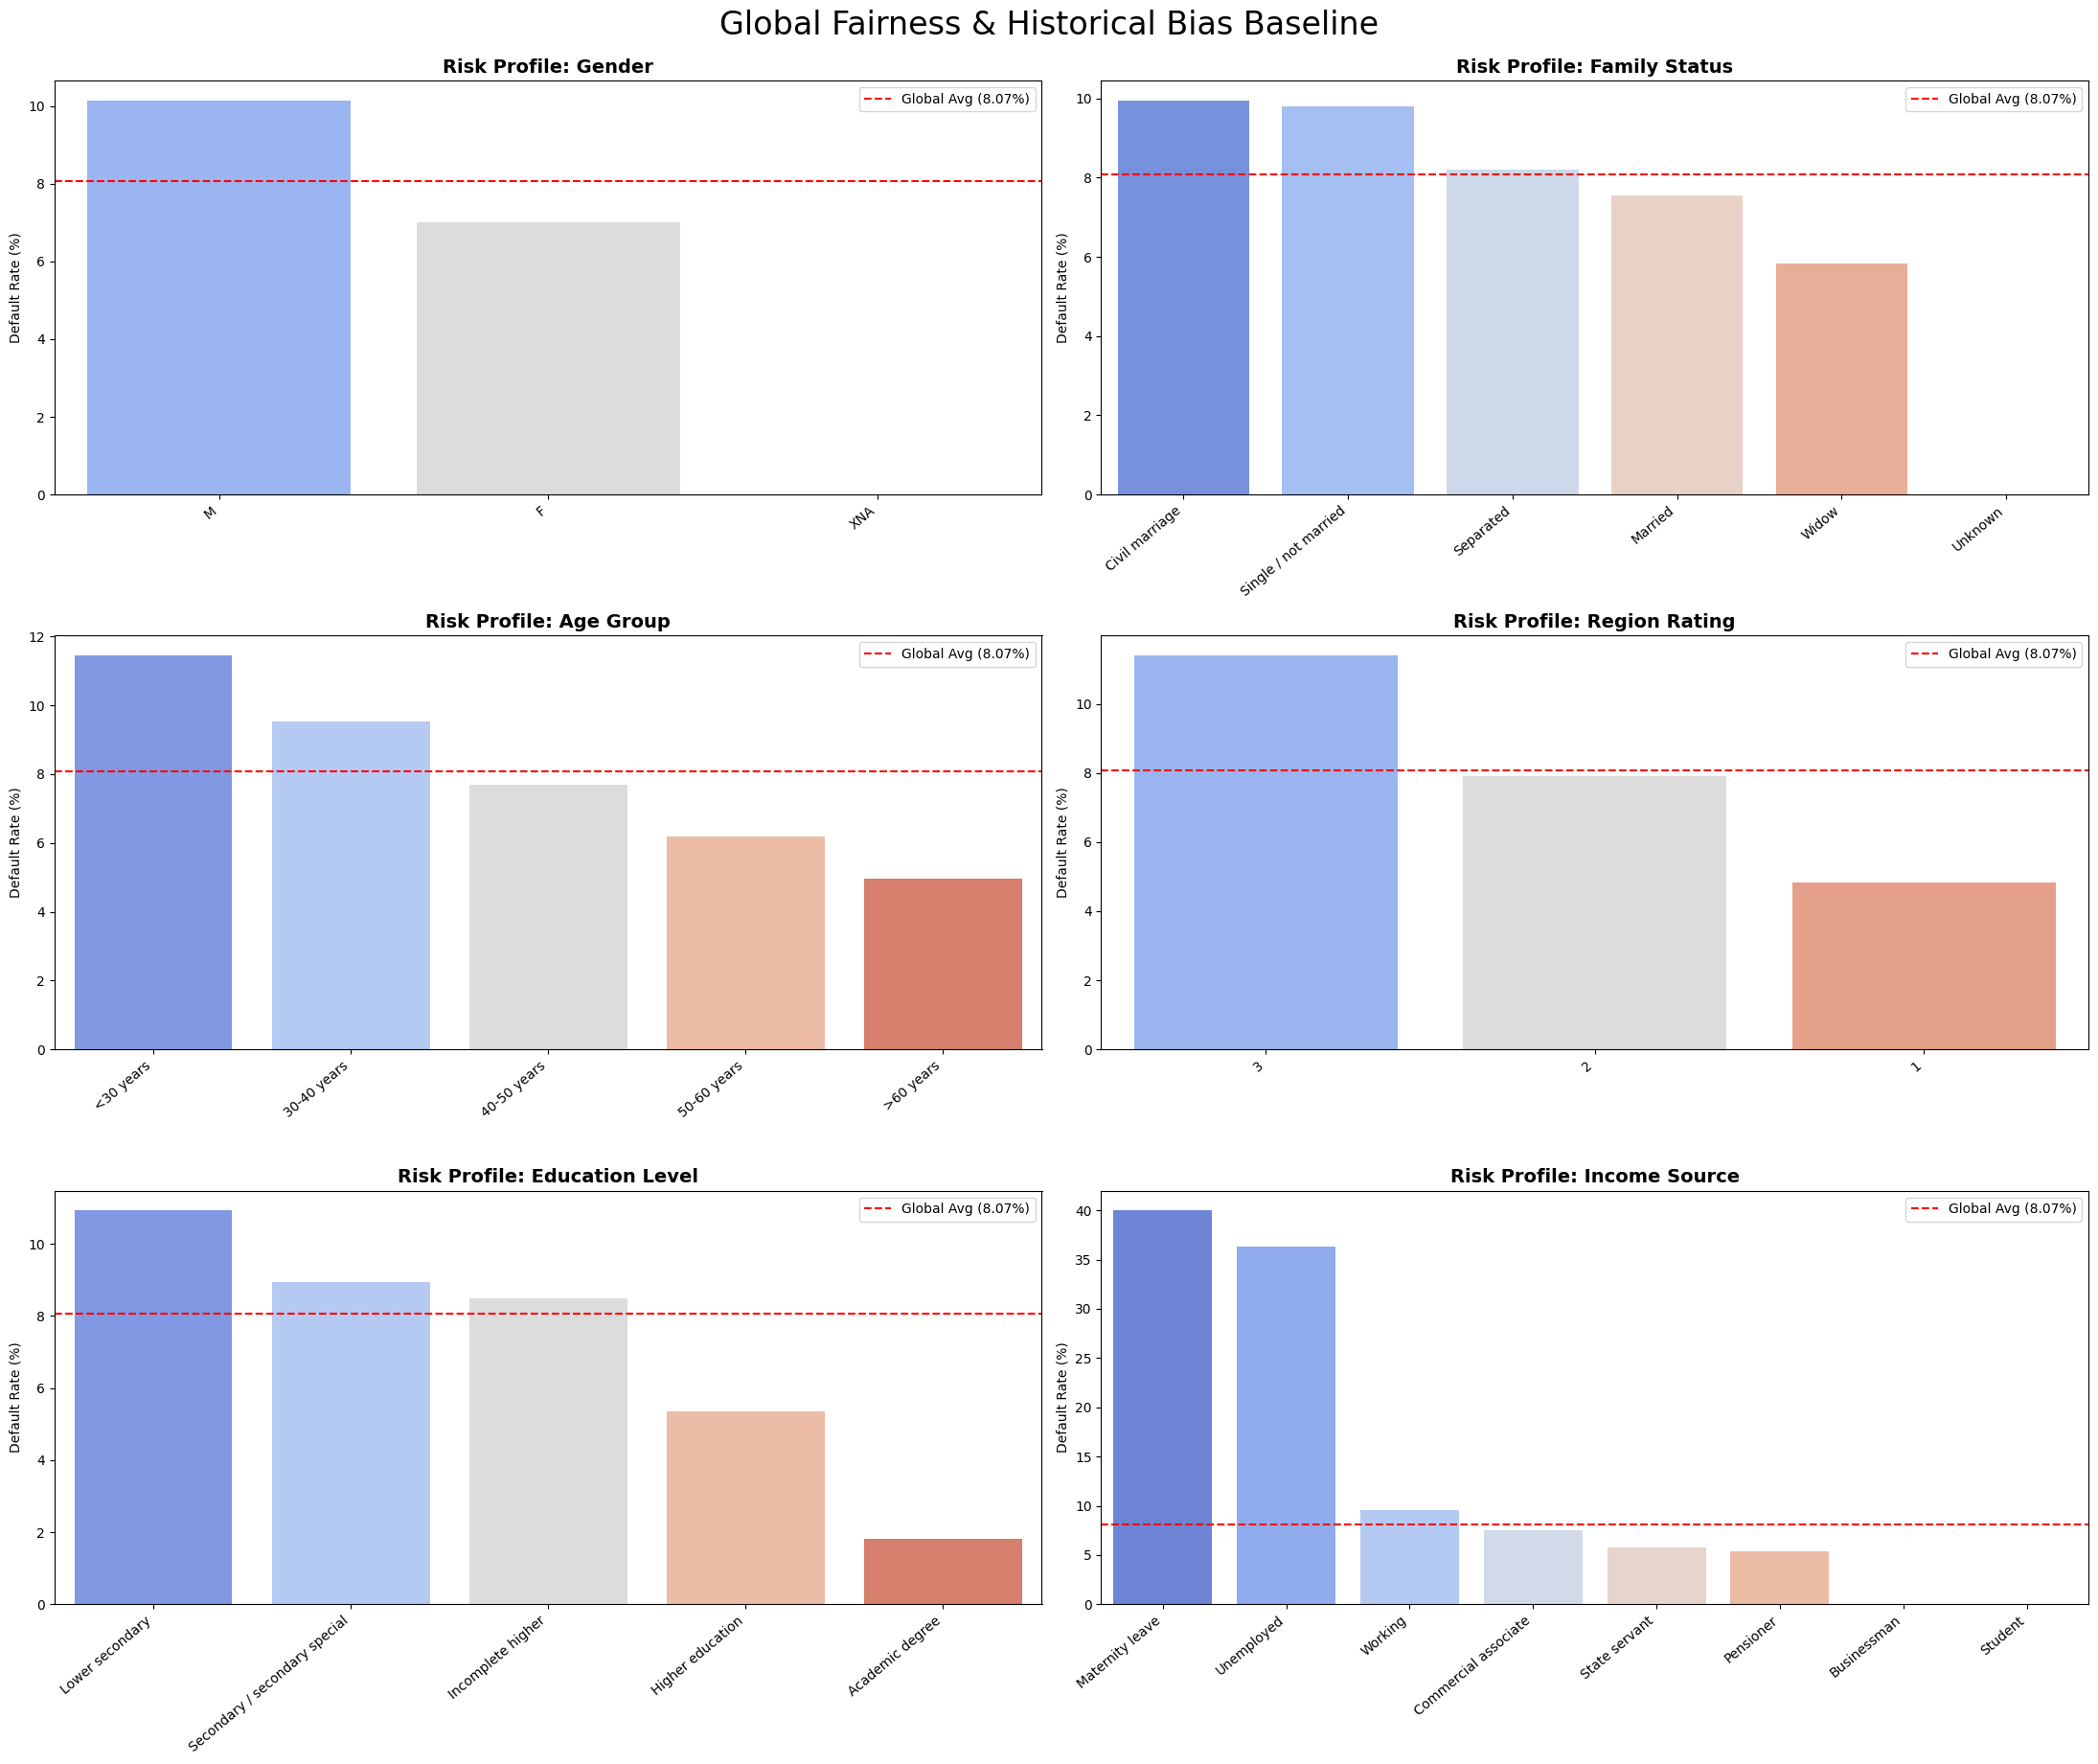


ROBUST DISPARATE IMPACT SUMMARY
      Attribute  Max_Risk_Ratio
Education Level        5.973795
  Region Rating        2.355372
      Age Group        2.306275
  Income Source        1.780137
  Family Status        1.707454
         Gender        1.448985


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

logger.info("Executing comprehensive fairness audit with robust risk ratio math...")

df_temp_audit = df_final_modeling.copy()

if 'YEARS_BIRTH' in df_temp_audit.columns:
    df_temp_audit['YEARS_BIRTH'] = pd.cut(
        df_temp_audit['YEARS_BIRTH'], 
        bins=5, 
        labels=['<30 years', '30-40 years', '40-50 years', '50-60 years', '>60 years']
    )

sensitive_cols = {
    'CODE_GENDER': 'Gender',
    'NAME_FAMILY_STATUS': 'Family Status',
    'YEARS_BIRTH': 'Age Group', 
    'REGION_RATING_CLIENT_W_CITY': 'Region Rating',
    'NAME_EDUCATION_TYPE': 'Education Level',
    'NAME_INCOME_TYPE': 'Income Source'
}

fairness_summary = []
global_avg = df_temp_audit['TARGET'].mean() * 100

fig, axes = plt.subplots(3, 2, figsize=(22, 18))
axes = axes.flatten()

for i, (col, label) in enumerate(sensitive_cols.items()):
    if col in df_temp_audit.columns:
        stats = df_temp_audit.groupby(col, observed=True)['TARGET'].agg(['mean', 'count'])
        stats['mean'] = stats['mean'] * 100
        stats = stats.sort_values(by='mean', ascending=False)
        
        valid_stats = stats[(stats['count'] >= 100) & (stats['mean'] > 0)]
        if not valid_stats.empty:
            risk_ratio = valid_stats['mean'].max() / valid_stats['mean'].min()
        else:
            risk_ratio = 1.0
            
        fairness_summary.append({'Attribute': label, 'Max_Risk_Ratio': risk_ratio})
        
        x_labels = [str(idx) for idx in stats.index]
        sns.barplot(x=x_labels, y=stats['mean'], palette='coolwarm', ax=axes[i])
        axes[i].axhline(global_avg, color='red', linestyle='--', label=f'Global Avg ({global_avg:.2f}%)')
        axes[i].set_title(f"Risk Profile: {label}", fontsize=14, fontweight='bold')
        axes[i].set_ylabel("Default Rate (%)")
        axes[i].set_xticklabels(x_labels, rotation=40, ha='right')
        axes[i].legend()

plt.tight_layout()
plt.suptitle("Global Fairness & Historical Bias Baseline", fontsize=24, y=1.02)
plt.show()

df_fairness_report = pd.DataFrame(fairness_summary).sort_values(by='Max_Risk_Ratio', ascending=False)
print("\n" + "="*50)
print("ROBUST DISPARATE IMPACT SUMMARY")
print("="*50)
print(df_fairness_report.to_string(index=False))
print("="*50)


### Key Insights from Historical Bias Audit

1. **Socio-Economic Barriers (Education & Income)**: 
   * **Education Level** represents the most extreme disparity in the dataset, with a **5.97x risk ratio**. Applicants with *Lower Secondary* education show a default rate nearly 6 times higher than those with an *Academic Degree*.
   * **Income Source** displays a moderate but significant risk gap (**1.78x risk ratio**), capturing the financial vulnerability of specific employment statuses relative to steady revenue streams.

2. **Regional & Demographic Gaps**:
   * **Region Rating**: Confirms a strong geographic risk concentration with a **2.35x risk ratio**, proving that regional economic infrastructure heavily influences baseline repayment probabilities.
   * **Gender**: A stable **1.45x risk ratio** is observed, indicating a historical baseline risk asymmetry between demographic segments.

3. **The "Stability" Proxy (Age & Family Status)**:
   * **Age Group**: Generates a substantial **2.30x risk ratio**, with younger applicants exhibiting significantly higher volatility compared to senior profiles. This directly reflects the "Lack of Credit History" and early-career instability bias common in retail banking.
   * **Family Status**: Shows a **1.70x risk ratio**, where civil status acts as an additional proxy for financial stability and household risk diversification.


#### **Strategic Decision for the Modeling Phase:**

*   **Risk vs. Discrimination**: While these variables are statistically significant (high AUC/IV), their direct use in a model can lead to **unfair automated decisions**.
*   **Compliance Strategy**: During the validation phase, we will measure if the **XGBoost model** amplifies these ratios. We will focus on "Equalized Odds"—ensuring that the model is equally accurate for a man as it is for a woman, regardless of their different historical default rates.

**Conclusion of the EDA**: 
We now have a **360° understanding** of the 80 features. We know which ones drive performance, which ones are redundant, and which ones carry ethical risks. The data is audited and ready for the **Preprocessing Pipeline**.